# 🎛️ Fine-Tuning LLMs — SFT, LoRA, QLoRA, and DPO

> **What you'll learn:** when fine-tuning beats prompting or RAG; how LLMs go from pretraining to instruction tuning to preference tuning; how SFT data is formatted and why prompt tokens are masked; the math and memory of full fine-tuning, LoRA, and QLoRA; how to run **SFT** and **DPO** with TRL on a laptop with real before/after evaluation; how to merge, save, and serve adapters; and how to check that the model did not forget what it already knew.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Hugging Face Transformers](../05_NLP/03_HuggingFace_Transformers.ipynb) (tokenizers, chat templates, `Trainer`, a first look at LoRA) · [Deep RL with Stable-Baselines3](../07_Reinforcement_Learning/02_Deep_RL_with_Stable_Baselines3.ipynb) (PPO, the RLHF / DPO / GRPO overview) |
| **Tested with** | Python 3.12 · torch 2.14 (Apple MPS; CUDA or CPU also work) · transformers 5.17 · peft 0.20 · trl 1.13 · datasets 5.0 |
| **Interview relevance** | ⭐⭐⭐ Very high — "fine-tune or RAG?", "explain LoRA rank and alpha", "how much memory does QLoRA save?", "why mask the prompt tokens?", "SFT vs DPO vs RLHF", "what does β do in DPO?", "how do you evaluate a fine-tuned model and detect forgetting?" |

## 🤔 What Is Fine-Tuning an LLM?

A pretrained LLM has read a huge amount of text, so it knows a lot of language and facts. **Fine-tuning** means *continuing to train* that model on a much smaller, carefully chosen dataset so it behaves the way **you** need: follow a format, speak in a style, solve a narrow task reliably, or prefer good answers over bad ones.

**Analogy — a new hire.** A new employee arrives with years of general education (pretraining). You don't send them back to school. You give them:

1. **A handbook of worked examples** — "when a customer writes X, answer like Y" → **supervised fine-tuning (SFT)**.
2. **Feedback on their drafts** — "this reply is better than that one" → **preference tuning** (RLHF with PPO, or **DPO**).
3. **Sticky notes instead of a rewritten brain** — small add-on modules that store the new habits → **LoRA** (and **QLoRA** when the employee's "brain" is compressed to fit a small desk).

```
 pretrained model ──SFT (demonstrations)──► instruction-following model ──DPO / RLHF (preferences)──► aligned model
       ▲                                            ▲
  trillions of tokens                        thousands of examples, often with LoRA adapters
```

Everything here runs on a laptop with **SmolLM2-135M-Instruct**, a tiny (135-million-parameter) chat model. The same code scales to 7B–70B models on GPUs; where the laptop cannot show something (4-bit QLoRA needs CUDA), the notebook computes the numbers and guards the GPU-only code honestly.

## 🎯 Why It Matters

- **It is how open models become products.** Companies adapt Llama, Qwen, Mistral, or Gemma models to their formats, tone, domain, and tasks — usually with **LoRA** adapters, because they are cheap to train, store, and serve.
- **Post-training is where assistants come from.** Every chat model you use went through SFT and preference tuning (RLHF, DPO, or a variant). Reasoning models add RL with verifiable rewards (GRPO-style).
- **The engineering decisions are expensive.** Choosing fine-tuning when RAG was needed (or the reverse), running out of GPU memory, silently training on prompt tokens, or shipping a model that forgot general skills all cost weeks.
- **In interviews** for AI/ML and LLM engineer roles you will be asked: *fine-tune vs RAG vs prompting*, *LoRA rank/alpha/target modules*, *QLoRA memory math*, *why mask the prompt*, *SFT vs RLHF vs DPO*, *what β and the reference model do*, *reward hacking*, *catastrophic forgetting*, and *how you evaluated your fine-tune*. Every one is practised below with runnable code.

## ✅ By the End You Can

- [ ] Decide between prompting, RAG, and fine-tuning for a use case — and justify it
- [ ] Format SFT data with chat templates, mask prompt tokens, and choose padding or packing
- [ ] Compute trainable parameters and memory for full fine-tuning, LoRA, and QLoRA
- [ ] Run SFT and DPO with TRL, evaluate before/after on held-out data, and check for forgetting
- [ ] Merge, save, reload, and hot-swap LoRA adapters
- [ ] Implement a LoRA layer and the DPO loss from scratch and prove they match PEFT and TRL

## 📋 Table of Contents

1. [When to Fine-Tune vs Prompt vs RAG](#1.-When-to-Fine-Tune-vs-Prompt-vs-RAG-🟢)
2. [The LLM Training Stages: Pretraining → SFT → Preference Tuning](#2.-The-LLM-Training-Stages:-Pretraining-→-SFT-→-Preference-Tuning-🟢)
3. [SFT Data: Chat Templates, Prompt Masking, Padding vs Packing](#3.-SFT-Data:-Chat-Templates,-Prompt-Masking,-Padding-vs-Packing-🟡)
4. [Full Fine-Tuning vs PEFT](#4.-Full-Fine-Tuning-vs-PEFT-🟢)
5. [LoRA Math: Rank, Alpha, Initialization, Target Modules](#5.-LoRA-Math:-Rank,-Alpha,-Initialization,-Target-Modules-🔴)
6. [QLoRA: 4-bit NF4, Double Quantization, Paged Optimizers](#6.-QLoRA:-4-bit-NF4,-Double-Quantization,-Paged-Optimizers-🔴)
7. [SFT with TRL — Before and After on a Held-Out Split](#7.-SFT-with-TRL-—-Before-and-After-on-a-Held-Out-Split-🟡)
8. [Saving, Reloading, and Merging Adapters](#8.-Saving,-Reloading,-and-Merging-Adapters-🟢)
9. [RLHF with PPO — A Recap](#9.-RLHF-with-PPO-—-A-Recap-🟡)
10. [DPO: The Objective, β, and the Reference Model](#10.-DPO:-The-Objective,-β,-and-the-Reference-Model-🔴)
11. [A Real DPO Run with DPOTrainer](#11.-A-Real-DPO-Run-with-DPOTrainer-🔴)
12. [GRPO and Other Variants — An Honest Overview](#12.-GRPO-and-Other-Variants-—-An-Honest-Overview-🟡)
13. [Catastrophic Forgetting: A General-Ability Probe](#13.-Catastrophic-Forgetting:-A-General-Ability-Probe-🟡)
14. [Hyperparameters and Common Failure Modes](#14.-Hyperparameters-and-Common-Failure-Modes-🟡)
15. [Serving Many LoRA Adapters on One Base Model](#15.-Serving-Many-LoRA-Adapters-on-One-Base-Model-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Text-to-SQL-Adapter) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**Downloads (once, cached by Hugging Face):** the model `HuggingFaceTB/SmolLM2-135M-Instruct` (~270 MB) and five small real datasets — `dair-ai/emotion` (~1.3 MB used), `jondurbin/truthy-dpo-v0.1` (~0.7 MB), `b-mc2/sql-create-context` (~22 MB), `allenai/ai2_arc` ARC-Easy (~0.4 MB), and WikiText-2 (~1 MB test split). No API keys and no local LLM server are needed: every model here is trained and evaluated directly with `transformers`, `peft`, and `trl`.

**What we limited, and why.** To keep the whole notebook around 10–15 minutes on an Apple-silicon laptop and under a few GB of memory, we use a 135M model, a few thousand training rows, one or two epochs, short sequences (≤ 256 tokens), and a few hundred evaluation rows. Absolute scores are therefore modest; the *method* (splits, metrics, before/after, forgetting checks) is exactly what you would use at 7B scale.

**Quiet logs.** Download bars and library warnings are turned off so saved outputs stay readable (`MLFLOW_DISABLE_AGENT_HINT` hides an informational log from MLflow, which TRL imports if it is installed). Turn logs back on with `transformers.logging.set_verbosity_warning()` while debugging.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.4" "transformers>=5.0" "peft>=0.17" "trl>=1.0" "datasets>=4.0" "accelerate>=1.0" scipy scikit-learn pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of the saved outputs
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")       # TRL imports MLflow when present; silence its hint log

import gc
import inspect
import json
import math
import re
import shutil
import sqlite3
import sys
import time
from pathlib import Path

import datasets
import huggingface_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import trl
from datasets import load_dataset
from peft import LoraConfig, PeftModel, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer

transformers.logging.set_verbosity_error()
datasets.disable_progress_bars()
huggingface_hub.utils.logging.set_verbosity_error()

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | transformers {transformers.__version__} | "
      f"peft {peft.__version__} | trl {trl.__version__} | datasets {datasets.__version__}")

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)

SEED = 42
transformers.set_seed(SEED)                               # seeds Python, NumPy, and torch in one call
pd.set_option("display.max_colwidth", 90)
OUTPUT_DIR = Path("_outputs") / "fine_tuning"             # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"


def free_memory():
    """Release cached accelerator memory after `del`-ing a model (important with limited RAM)."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_model(dtype=torch.float32):
    """A fresh copy of the base chat model on DEVICE (float32 keeps small-model training stable on MPS)."""
    return AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=dtype).to(DEVICE)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool)) or b is None:
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and set(a) == set(b) and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)) and isinstance(a, (list, tuple)) and any(isinstance(x, (list, tuple, dict, str)) for x in b):
            return len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        try:                                   # numbers, arrays, tensors
            a_arr = np.asarray(a.detach().cpu() if isinstance(a, torch.Tensor) else a, dtype=float)
            b_arr = np.asarray(b.detach().cpu() if isinstance(b, torch.Tensor) else b, dtype=float)
        except (TypeError, ValueError):
            return a == b
        return a_arr.shape == b_arr.shape and bool(np.allclose(a_arr, b_arr, atol=atol, rtol=1e-6))

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | transformers 5.17.0 | peft 0.20.0 | trl 1.13.0 | datasets 5.0.1
device: mps


## 1. When to Fine-Tune vs Prompt vs RAG 🟢

Three ways to make an LLM do what you want, cheapest first:

| Approach | What changes | Best for | Weak at |
|---|---|---|---|
| **Prompting** (instructions + few-shot examples) | nothing in the model | quick prototypes, general tasks, changing requirements | long, repeated instructions cost tokens on every call; fragile formats |
| **RAG** (retrieve documents, put them in the prompt) | nothing in the model | **knowledge**: private, fresh, or citable facts | teaching a new *behaviour*, style, or output format |
| **Fine-tuning** (SFT, then maybe DPO) | the weights (or small adapters) | **behaviour**: formats, tone, narrow tasks, smaller/cheaper models matching a big model on one task | adding facts that change often; needs good data and evaluation |

**The one rule to remember:** *RAG for knowledge, fine-tuning for behaviour, prompting first for everything.* They combine well — a fine-tuned model that is good at *using* retrieved context is common in production.

Worked examples:

| Scenario | Pick | Why |
|---|---|---|
| Answer employees' questions about this quarter's HR policies | **RAG** | facts change and answers need citations |
| Always return valid JSON with our 40-field schema | **fine-tune** (or structured output first) | a *format* learned from examples; saves long prompts |
| Classify 5M support tickets per day into 12 intents cheaply | **fine-tune a small model** | high volume → latency and cost dominate |
| Summarize a meeting once for a demo tomorrow | **prompting** | no data, no time, low volume |
| Doctor-facing assistant using the latest guidelines in the house style | **RAG + fine-tune** | knowledge via retrieval, style via SFT |

Below, the same guide as a tiny function — a teaching heuristic, not a law.

In [2]:
def choose_approach(needs_private_or_fresh_facts, needs_new_behaviour_or_format, has_hundreds_of_examples, high_volume_or_latency_critical):
    """Return the recommended starting approach for an LLM use case."""
    if needs_private_or_fresh_facts and needs_new_behaviour_or_format and has_hundreds_of_examples:
        return "RAG + fine-tuning"
    if needs_private_or_fresh_facts:
        return "RAG"
    if (needs_new_behaviour_or_format or high_volume_or_latency_critical) and has_hundreds_of_examples:
        return "fine-tuning"
    return "prompting"


scenarios = {
    "HR policy Q&A (changes quarterly)": (True, False, False, False),
    "strict 40-field JSON extraction": (False, True, True, False),
    "5M tickets/day intent classification": (False, False, True, True),
    "one-off meeting summary": (False, False, False, False),
    "clinical assistant in house style": (True, True, True, False),
}
pd.DataFrame([{"scenario": s, "recommendation": choose_approach(*flags)} for s, flags in scenarios.items()])

,scenario,recommendation
0,HR policy Q&A (changes quarterly),RAG
1,strict 40-field JSON extraction,fine-tuning
2,5M tickets/day intent classification,fine-tuning
3,one-off meeting summary,prompting
4,clinical assistant in house style,RAG + fine-tuning


### ✍️ Your Turn

A legal team wants a model that drafts contract clauses **in the firm's exact house style**. They have 3,000 past clauses written by partners; the law itself is not part of the task. Call `choose_approach` with the right flags and store the result in `legal_pick`.

In [3]:
legal_pick = None  # TODO: your code here
check("legal_pick", legal_pick, "fine-tuning", hint="No fresh facts are needed; a style/format is; they have thousands of examples.")

⏳ legal_pick: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
legal_pick = choose_approach(needs_private_or_fresh_facts=False, needs_new_behaviour_or_format=True,
                             has_hundreds_of_examples=True, high_volume_or_latency_critical=False)
check("legal_pick", legal_pick, "fine-tuning")
```

Style is behaviour, not knowledge. You would still start with a few-shot prompt as a baseline and fine-tune only if the evaluation shows the prompt is not enough.
</details>

> 💡 **Interview angle:** "Fine-tune or RAG?" — RAG when the problem is *knowledge* (private, changing, must be cited); fine-tuning when it is *behaviour* (format, tone, a narrow task, a smaller cheaper model). Start with prompting as the baseline, and decide with an evaluation set, not intuition. Fine-tuning is a poor way to add facts that change, and it does not give citations.

## 2. The LLM Training Stages: Pretraining → SFT → Preference Tuning 🟢

| Stage | Data | Objective | Scale (typical) | Result |
|---|---|---|---|---|
| **Pretraining** | raw web, books, code | predict the next token on **every** token | trillions of tokens, thousands of GPUs | a *base* model that continues text |
| **SFT** (supervised fine-tuning / instruction tuning) | (prompt, ideal response) pairs, often chat-formatted | next-token loss on the **response tokens only** | 10k–1M examples | an *instruct* model that follows requests |
| **Preference tuning** | (prompt, chosen, rejected) comparisons | RLHF (reward model + PPO) or DPO-style losses | 10k–1M comparisons | a model that prefers helpful, honest, safe answers |
| *(optional)* **RL with verifiable rewards** | prompts with checkable answers (math, code tests) | GRPO / PPO on the reward | many sampled answers per prompt | stronger step-by-step reasoning |

The key insight: **SFT uses exactly the pretraining loss** — next-token cross-entropy — just on different data and only on some tokens. Let's compute that loss by hand and check it against the model's built-in loss.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = load_model()
print(f"{MODEL_ID}: {sum(p.numel() for p in model.parameters()):,} parameters | vocab {len(tokenizer):,} | "
      f"pad token {tokenizer.pad_token!r} | eos token {tokenizer.eos_token!r}")

text = "Fine-tuning adapts a pretrained language model to a new task."
enc = tokenizer(text, return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    out = model(**enc, labels=enc["input_ids"])                      # transformers shifts the labels internally

logits = out.logits[:, :-1, :].float()                               # position t predicts token t+1
targets = enc["input_ids"][:, 1:]
manual_loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
print(f"built-in loss {out.loss.item():.4f} | manual next-token cross-entropy {manual_loss.item():.4f} | "
      f"perplexity exp(loss) = {math.exp(manual_loss.item()):.1f}")
assert abs(out.loss.item() - manual_loss.item()) < 1e-3

HuggingFaceTB/SmolLM2-135M-Instruct: 134,515,008 parameters | vocab 49,152 | pad token '<|im_end|>' | eos token '<|im_end|>'


built-in loss 4.0186 | manual next-token cross-entropy 4.0186 | perplexity exp(loss) = 55.6


**Perplexity** = `exp(mean next-token loss)`: roughly "how many equally likely tokens the model is choosing between". Lower is better. We will use it in Section 13 to check for forgetting.

### ✍️ Your Turn

A model has a mean next-token loss of `2.0` nats on a validation text. Store its perplexity in `ppl_from_loss`.

In [5]:
ppl_from_loss = None  # TODO: your code here
check("ppl_from_loss", ppl_from_loss, 7.389056, atol=1e-5, hint="math.exp(loss)")

⏳ ppl_from_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ppl_from_loss = math.exp(2.0)
check("ppl_from_loss", ppl_from_loss, 7.389056, atol=1e-5)
```
</details>

> 💡 **Interview angle:** "How is SFT different from pretraining?" — same next-token cross-entropy, but on curated (prompt, response) data formatted with the chat template, and usually with the loss masked to the response tokens. Preference tuning is a different objective: it compares two responses to the same prompt.

## 3. SFT Data: Chat Templates, Prompt Masking, Padding vs Packing 🟡

TRL's `SFTTrainer` accepts four dataset shapes:

| Format | Row looks like | Loss on |
|---|---|---|
| language modeling | `{"text": "..."}` | every token |
| conversational language modeling | `{"messages": [{"role": "user", ...}, {"role": "assistant", ...}]}` | every token (or only assistant turns with `assistant_only_loss=True`, which needs a template that marks them) |
| prompt–completion | `{"prompt": "...", "completion": "..."}` | **completion only** by default (`completion_only_loss`) |
| conversational prompt–completion | `{"prompt": [messages], "completion": [assistant message]}` | **completion only** by default |

Our SFT task: **emotion classification** of short English tweets from `dair-ai/emotion` (6 labels; the dataset card restricts it to educational and research use). We frame it as a chat request so a *generative* model learns to answer with one word — a narrow, measurable behaviour.

In [6]:
emotion = load_dataset("dair-ai/emotion", "split")
EMOTIONS = emotion["train"].features["label"].names
print(emotion)
print("labels:", EMOTIONS)


def emotion_prompt(text):
    return [{"role": "user", "content": f"Classify the emotion of this text as one of: {', '.join(EMOTIONS)}.\n"
                                        f"Text: {text}\nAnswer with one word."}]


def to_prompt_completion(row):
    return {"prompt": emotion_prompt(row["text"]),
            "completion": [{"role": "assistant", "content": EMOTIONS[row["label"]]}]}


example = to_prompt_completion(emotion["train"][0])
print(json.dumps(example, indent=1))
rendered = tokenizer.apply_chat_template(example["prompt"] + example["completion"], tokenize=False)
print(rendered)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
{
 "prompt": [
  {
   "role": "user",
   "content": "Classify the emotion of this text as one of: sadness, joy, love, anger, fear, surprise.\nText: i didnt feel humiliated\nAnswer with one word."
  }
 ],
 "completion": [
  {
   "role": "assistant",
   "content": "sadness"
  }
 ]
}
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Classify the emotion of this text as one of: sadness, joy, love, anger, fear, surprise.
Text: i didnt feel humiliated
Answer with one word.<|im_end|>
<|im_start|>assistant
sadness<|im_end|>



The template wraps every turn in `<|im_start|>role … <|im_end|>` and, because we gave no system message, SmolLM2's template inserts a default one. **Training and inference must use the same template** — Pitfall 2 measures what happens when they don't.

**Prompt masking.** Labels are a copy of the input ids, with `-100` wherever we do **not** want loss. PyTorch's cross-entropy ignores `-100`. For SFT we mask the prompt, so the model is graded only on what it should *write*:

In [7]:
def build_sft_example(prompt_messages, completion_messages):
    """input_ids for prompt+completion and labels with the prompt masked (-100)."""
    prompt_ids = tokenizer.apply_chat_template(prompt_messages, add_generation_prompt=True, tokenize=True, return_dict=True)["input_ids"]
    full_ids = tokenizer.apply_chat_template(prompt_messages + completion_messages, tokenize=True, return_dict=True)["input_ids"]
    assert full_ids[:len(prompt_ids)] == prompt_ids, "the prompt must be a prefix of the full conversation"
    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    return {"input_ids": full_ids, "labels": labels}


manual_example = build_sft_example(example["prompt"], example["completion"])
n_total, n_loss = len(manual_example["labels"]), sum(l != -100 for l in manual_example["labels"])
print(f"{n_total} tokens, {n_loss} with loss ({n_loss / n_total:.0%}) → the rest are prompt tokens\n")
tail = pd.DataFrame({"token": tokenizer.convert_ids_to_tokens(manual_example["input_ids"])[-8:],
                     "input_id": manual_example["input_ids"][-8:], "label": manual_example["labels"][-8:]})
print(tail.to_string(index=False))

73 tokens, 5 with loss (7%) → the rest are prompt tokens

     token  input_id  label
       ass       520   -100
    istant      9531   -100
         Ċ       198   -100
         s        99     99
        ad       344    344
      ness       924    924
<|im_end|>         2      2
         Ċ       198    198


Only the answer word(s), the end-of-turn token `<|im_end|>`, and the newline after it are trained. **Learning to emit `<|im_end|>` is what teaches the model to stop** — so never mask it (Pitfall 3).

How much does masking change the loss? Same model, same example, two label choices:

In [8]:
def mean_loss(input_ids, labels):
    ids = torch.tensor([input_ids], device=DEVICE)
    with torch.inference_mode():
        return model(input_ids=ids, labels=torch.tensor([labels], device=DEVICE)).loss.item()


loss_all_tokens = mean_loss(manual_example["input_ids"], manual_example["input_ids"])
loss_response_only = mean_loss(manual_example["input_ids"], manual_example["labels"])
print(f"mean loss over ALL tokens     : {loss_all_tokens:.3f}  ({n_total - 1} predicted tokens)")
print(f"mean loss over RESPONSE tokens: {loss_response_only:.3f}  ({n_loss} predicted tokens)")
print("→ without masking, the gradient is dominated by re-learning the fixed instruction text, not the answer.")

mean loss over ALL tokens     : 3.498  (72 predicted tokens)
mean loss over RESPONSE tokens: 1.062  (5 predicted tokens)
→ without masking, the gradient is dominated by re-learning the fixed instruction text, not the answer.


**Padding vs packing.** A batch is a rectangle, so short examples get **padding** — compute spent on nothing. Two fixes:

- **Group by length** (`group_by_length=True`): batch similar lengths together → less padding.
- **Packing** (`packing=True`): concatenate several examples into one fixed-length row → almost no padding. TRL's default `packing_strategy="bfd"` (best-fit decreasing) keeps each example whole and records where it starts so that attention implementations supporting variable-length sequences (e.g. FlashAttention with `padding_free`) don't let one example attend to another. With a plain attention kernel, packed examples *can* see each other — one reason packing is usually reserved for large runs on GPUs.

Let's measure the waste on 2,000 real training examples.

In [9]:
from trl import pack_dataset

sft_pool = emotion["train"].shuffle(seed=SEED).select(range(2_000))
lengths = np.array([len(build_sft_example(emotion_prompt(t), [{"role": "assistant", "content": EMOTIONS[l]}])["input_ids"])
                    for t, l in zip(sft_pool["text"], sft_pool["label"])])
BATCH = 16


def padding_share(lens, batch_size):
    real = padded = 0
    for i in range(0, len(lens), batch_size):
        chunk = lens[i:i + batch_size]
        real += chunk.sum()
        padded += chunk.max() * len(chunk)
    return 1 - real / padded


token_rows = datasets.Dataset.from_dict({"input_ids": [[0] * int(n) for n in lengths]})
packed = pack_dataset(token_rows, seq_length=512)
packed_lengths = np.array([len(ids) for ids in packed["input_ids"]])
print(f"example lengths: median {np.median(lengths):.0f}, max {lengths.max()} tokens")
print(f"random batches of {BATCH}: {padding_share(lengths, BATCH):.1%} of batch tokens are padding")
print(f"length-sorted batches  : {padding_share(np.sort(lengths), BATCH):.1%} padding")
print(f"packing into 512-token rows: {len(lengths):,} examples → {len(packed):,} rows, "
      f"{1 - packed_lengths.sum() / (512 * len(packed)):.1%} empty space | packed columns: {packed.column_names}")

example lengths: median 84, max 130 tokens
random batches of 16: 22.6% of batch tokens are padding
length-sorted batches  : 0.3% padding
packing into 512-token rows: 2,000 examples → 358 rows, 5.8% empty space | packed columns: ['input_ids', 'seq_lengths']


### ✍️ Your Turn

Using `build_sft_example`, count the number of tokens that receive loss for the **second** training example of `sft_pool` (text `sft_pool[1]["text"]`, label `EMOTIONS[sft_pool[1]["label"]]`). Store it in `n_trained_tokens`.

In [10]:
n_trained_tokens = None  # TODO: your code here
_row = sft_pool[1]
_ref = build_sft_example(emotion_prompt(_row["text"]), [{"role": "assistant", "content": EMOTIONS[_row["label"]]}])
check("n_trained_tokens", n_trained_tokens, sum(l != -100 for l in _ref["labels"]),
      hint="Build the example, then count labels that are not -100.")

⏳ n_trained_tokens: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
row = sft_pool[1]
ex = build_sft_example(emotion_prompt(row["text"]), [{"role": "assistant", "content": EMOTIONS[row["label"]]}])
n_trained_tokens = sum(label != -100 for label in ex["labels"])
check("n_trained_tokens", n_trained_tokens, sum(l != -100 for l in ex["labels"]))
```

The count is the answer's tokens plus `<|im_end|>` and the newline — a handful out of dozens of tokens.
</details>

> 💡 **Interview angle:** "Why mask the prompt tokens?" — the prompt is given at inference, so learning to predict it wastes capacity and gradient; with long prompts and short answers, unmasked loss is dominated by the prompt, and the model can learn to parrot instructions. Keep the end-of-turn/EOS token in the labels so the model learns to stop.

## 4. Full Fine-Tuning vs PEFT 🟢

**Full fine-tuning** updates every weight. With the Adam optimizer in mixed precision, each parameter needs about **16 bytes** of *model state* before any activations:

| Tensor | Bytes / parameter |
|---|---|
| 16-bit weights (bf16/fp16) used in forward/backward | 2 |
| 16-bit gradients | 2 |
| fp32 **master** copy of the weights | 4 |
| Adam first moment (momentum), fp32 | 4 |
| Adam second moment (variance), fp32 | 4 |
| **Total** | **16** |

(The [Distributed Training Overview](09_Distributed_Training_Overview.ipynb) derives this in detail.) **PEFT** (parameter-efficient fine-tuning) freezes the base model and trains a tiny number of new parameters, so gradients and optimizer states exist only for those:

| PEFT method | What it trains |
|---|---|
| **LoRA** | low-rank matrices added beside chosen linear layers (can be merged away) |
| **QLoRA** | LoRA on top of a 4-bit quantized frozen base |
| **DoRA**, **rsLoRA** | LoRA variants: magnitude/direction split; α/√r scaling |
| prompt / prefix tuning | learned "virtual token" vectors |
| adapters, (IA)³ | small bottleneck layers; learned scaling vectors |

In [11]:
def full_ft_state_gb(n_params, bytes_per_param=16):
    return n_params * bytes_per_param / 1e9


def lora_state_gb(n_params, n_trainable, frozen_bytes=2):
    """Frozen base in 16-bit + 16 bytes of state for each trainable parameter."""
    return (n_params * frozen_bytes + n_trainable * 16) / 1e9


n_smol = sum(p.numel() for p in model.parameters())
sizes = {"SmolLM2-135M (this notebook)": n_smol, "0.5B": 0.5e9, "7B": 7e9, "13B": 13e9, "70B": 70e9}
rows = []
for name, n in sizes.items():
    trainable = 0.005 * n                                               # LoRA often trains ~0.1–1% of parameters
    rows.append({"model": name, "params (B)": n / 1e9, "full FT model states (GB)": full_ft_state_gb(n),
                 "LoRA ~0.5% trainable (GB)": lora_state_gb(n, trainable), "savings ×": full_ft_state_gb(n) / lora_state_gb(n, trainable)})
pd.DataFrame(rows).round(2)

,model,params (B),full FT model states (GB),LoRA ~0.5% trainable (GB),savings ×
0,SmolLM2-135M (this notebook),0.13,2.15,0.28,7.69
1,0.5B,0.50,8.00,1.04,7.69
2,7B,7.00,112.00,14.56,7.69
3,13B,13.00,208.00,27.04,7.69
4,70B,70.00,1120.00,145.60,7.69


Model states only — activations come on top and grow with batch size × sequence length (gradient checkpointing trades them for recomputation). Even so, the table shows why a 7B **full** fine-tune needs data-center GPUs (>100 GB) while **LoRA** fits on one 24–48 GB card.

### ✍️ Your Turn

Store the model-state memory in GB for full fine-tuning a **1.5B** parameter model with mixed-precision Adam in `gb_1p5b`.

In [12]:
gb_1p5b = None  # TODO: your code here
check("gb_1p5b", gb_1p5b, 24.0, hint="parameters × 16 bytes / 1e9")

⏳ gb_1p5b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gb_1p5b = full_ft_state_gb(1.5e9)
check("gb_1p5b", gb_1p5b, 24.0)
```

The ZeRO paper uses exactly this example: a 1.5B GPT-2 needs 3 GB for its fp16 weights but at least 24 GB of model states to train.
</details>

> 💡 **Interview angle:** "Full fine-tuning or LoRA?" — LoRA: ~10× less memory, tiny checkpoints, many adapters on one base, less forgetting, and usually close in quality for narrow tasks. Full fine-tuning: best when you have lots of data and the task is far from pretraining (new language, heavy domain shift), and you can afford the memory.

## 5. LoRA Math: Rank, Alpha, Initialization, Target Modules 🔴

For a frozen weight $W \in \mathbb{R}^{d_\text{out} \times d_\text{in}}$, LoRA learns $A \in \mathbb{R}^{r \times d_\text{in}}$ and $B \in \mathbb{R}^{d_\text{out} \times r}$:

$$h = W x + \frac{\alpha}{r}\, B A x \qquad\Rightarrow\qquad W_\text{merged} = W + \frac{\alpha}{r} B A$$

| Knob | Meaning | Typical |
|---|---|---|
| `r` (rank) | width of the bottleneck; trainable params per matrix = $r(d_\text{in} + d_\text{out})$ | 8–64 |
| `lora_alpha` | scale; the update is multiplied by α/r so changing r doesn't force a new learning rate | α = r or 2r |
| initialization | **A** random (Kaiming-uniform in PEFT), **B = 0** → $BA = 0$, so training starts exactly at the base model | default |
| `target_modules` | which linear layers get adapters: attention `q_proj,k_proj,v_proj,o_proj`, MLP `gate_proj,up_proj,down_proj`, or `"all-linear"` | all-linear for LLMs |
| `use_rslora` | scale by α/√r instead — keeps large ranks stable | off by default |

Why can a low-rank update work? Fine-tuning changes turn out to have low "intrinsic rank": a few directions carry most of the adaptation (the LoRA paper found tiny ranks often sufficed for GPT-3).

Let's look at SmolLM2's linear layers. Note `k_proj`/`v_proj` are **smaller** than `q_proj`: the model uses grouped-query attention (3 key/value heads shared by 9 query heads).

In [13]:
layer0 = model.model.layers[0]
linear_shapes = {name: (m.in_features, m.out_features) for name, m in layer0.named_modules() if isinstance(m, nn.Linear)}
print("layer 0 linear layers (in → out):", linear_shapes)
print("number of decoder layers:", model.config.num_hidden_layers)


def lora_params(model, target_names, r):
    """Trainable LoRA parameters: r·(d_in + d_out) for every nn.Linear whose last name part is targeted."""
    total = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and name.split(".")[-1] in target_names and "lm_head" not in name:
            total += r * (module.in_features + module.out_features)
    return total


TARGETS = {
    "q,v (LoRA paper)": ["q_proj", "v_proj"],
    "all attention": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "all-linear": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
}
table = pd.DataFrame({f"r={r}": {k: lora_params(model, v, r) for k, v in TARGETS.items()} for r in [4, 8, 16, 64]})
print("trainable LoRA parameters (share of the 135M model):")
print(table.map(lambda n: f"{n:,} ({n / n_smol:.2%})").to_string())

layer 0 linear layers (in → out): {'self_attn.q_proj': (576, 576), 'self_attn.k_proj': (576, 192), 'self_attn.v_proj': (576, 192), 'self_attn.o_proj': (576, 576), 'mlp.gate_proj': (576, 1536), 'mlp.up_proj': (576, 1536), 'mlp.down_proj': (1536, 576)}
number of decoder layers: 30
trainable LoRA parameters (share of the 135M model):
                                r=4                r=8               r=16                 r=64
q,v (LoRA paper)    230,400 (0.17%)    460,800 (0.34%)    921,600 (0.69%)    3,686,400 (2.74%)
all attention       460,800 (0.34%)    921,600 (0.69%)  1,843,200 (1.37%)    7,372,800 (5.48%)
all-linear        1,221,120 (0.91%)  2,442,240 (1.82%)  4,884,480 (3.63%)  19,537,920 (14.52%)


Cross-check our formula against PEFT, and prove the "B = 0" claim: a freshly wrapped model produces **identical** logits.

In [14]:
probe_ids = tokenizer("LoRA starts from the base model.", return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    base_logits = model(**probe_ids).logits

expected_all_linear = lora_params(model, TARGETS["all-linear"], 16)       # count BEFORE wrapping: PEFT edits the model in place
peft_probe = get_peft_model(model, LoraConfig(r=16, lora_alpha=32, target_modules="all-linear", task_type="CAUSAL_LM"))
trainable, total = peft_probe.get_nb_trainable_parameters()
print(f"PEFT trainable {trainable:,} of {total:,} ({trainable / total:.2%}) | our formula {expected_all_linear:,}")
assert trainable == expected_all_linear

q_lora = peft_probe.base_model.model.model.layers[0].self_attn.q_proj
print("wrapped q_proj:", type(q_lora).__name__, "| A", tuple(q_lora.lora_A["default"].weight.shape),
      "| B", tuple(q_lora.lora_B["default"].weight.shape), "| scaling α/r =", q_lora.scaling["default"],
      "| B all zeros:", bool((q_lora.lora_B["default"].weight == 0).all()))
with torch.inference_mode():
    wrapped_logits = peft_probe(**probe_ids).logits
print(f"max |logit difference| right after wrapping: {(wrapped_logits - base_logits).abs().max().item():.1e}")
assert torch.equal(wrapped_logits, base_logits)
model = peft_probe.unload()                     # remove the adapters again → the plain base model
del peft_probe, q_lora
free_memory()

PEFT trainable 4,884,480 of 139,399,488 (3.50%) | our formula 4,884,480
wrapped q_proj: Linear | A (16, 576) | B (576, 16) | scaling α/r = 2.0 | B all zeros: True
max |logit difference| right after wrapping: 0.0e+00


**Memory estimate for a real 7B model.** A Llama-2-7B-shaped model has hidden size 4096, MLP size 11008, 32 layers, and full multi-head attention (all four attention projections are 4096 × 4096).

In [15]:
def lora_params_from_dims(hidden, intermediate, layers, r, kv_dim=None):
    kv_dim = kv_dim or hidden
    attention = (hidden + hidden) + (hidden + kv_dim) * 2 + (hidden + hidden)      # q, k, v, o
    mlp = (hidden + intermediate) * 2 + (intermediate + hidden)                     # gate, up, down
    return layers * r * (attention + mlp)


n7b = 6.74e9
lora_7b = lora_params_from_dims(4096, 11008, 32, r=16)
print(f"7B all-linear LoRA r=16: {lora_7b:,} trainable parameters ({lora_7b / n7b:.2%})")
print(f"model states: full FT {full_ft_state_gb(n7b):.0f} GB | LoRA (bf16 base) {lora_state_gb(n7b, lora_7b):.1f} GB | "
      f"adapter file in bf16 ≈ {lora_7b * 2 / 1e6:.0f} MB")

7B all-linear LoRA r=16: 39,976,960 trainable parameters (0.59%)
model states: full FT 108 GB | LoRA (bf16 base) 14.1 GB | adapter file in bf16 ≈ 80 MB


### ✍️ Your Turn

How many trainable parameters does LoRA with `r=8` add to **one** `nn.Linear(576, 1536)` (SmolLM2's `up_proj`)? Store it in `up_proj_lora`.

In [16]:
up_proj_lora = None  # TODO: your code here
check("up_proj_lora", up_proj_lora, 16_896, hint="r × (d_in + d_out)")

⏳ up_proj_lora: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
up_proj_lora = 8 * (576 + 1536)
check("up_proj_lora", up_proj_lora, 16_896)
```

A is 8 × 576 = 4,608 and B is 1536 × 8 = 12,288. The frozen matrix has 576 × 1536 = 884,736 weights — LoRA adds under 2%.
</details>

> 💡 **Interview angle:** "Explain LoRA's rank, alpha, and targets." — ΔW = (α/r)·B·A with r ≪ d; params per matrix r(d_in + d_out); B is zero-initialized so step 0 equals the base model; α/r keeps the update scale stable across ranks (rsLoRA uses α/√r); adapting all linear layers beats attention-only for LLMs at the same parameter budget in most reports; merge for zero added latency.

## 6. QLoRA: 4-bit NF4, Double Quantization, Paged Optimizers 🔴

**QLoRA** (Dettmers et al., 2023) freezes the base model in **4-bit** and trains 16-bit LoRA adapters on top. Gradients flow *through* the dequantized 4-bit weights into the adapters. Three ideas make it work:

1. **NF4 (4-bit NormalFloat)** — pretrained weights are roughly normally distributed, so the 16 code values are placed at **quantiles of a normal distribution** instead of evenly spaced. Weights are quantized in **blocks of 64**, each block scaled by its own absolute maximum (stored as a 32-bit "quantization constant").
2. **Double quantization** — those per-block constants cost 32/64 = 0.5 bits per parameter. Quantizing *them* to 8 bits in blocks of 256 cuts the overhead to 8/64 + 32/(64·256) ≈ 0.127 bits.
3. **Paged optimizers** — optimizer states live in NVIDIA unified memory and are paged to CPU RAM during rare memory spikes (e.g. a long sequence) instead of crashing with out-of-memory.

Let's build the NF4 codebook the way the paper and `bitsandbytes` do (8 positive quantiles, 7 negative, and an exact zero) and measure its error on **real SmolLM2 weights** against evenly spaced 4-bit levels.

In [17]:
from scipy.stats import norm


def nf4_codebook(offset=0.9677083):
    positive = norm.ppf(np.linspace(offset, 0.5, 9)[:-1])        # 8 positive normal quantiles
    negative = -norm.ppf(np.linspace(offset, 0.5, 8)[:-1])       # 7 negative ones → asymmetric, keeps an exact 0
    values = np.sort(np.concatenate([positive, [0.0], negative]))
    return torch.tensor(values / values.max(), dtype=torch.float32)


NF4 = nf4_codebook()
PUBLISHED_NF4 = [-1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, 0.0,
                 0.0796, 0.1609, 0.2461, 0.3379, 0.4407, 0.5626, 0.7230, 1.0]   # the NF4 table in bitsandbytes
print("NF4 codebook:", NF4.numpy().round(4))
assert np.allclose(NF4.numpy(), PUBLISHED_NF4, atol=1e-4)
UNIFORM4 = torch.linspace(-1, 1, 16)


def blockwise_quantize(weight, codebook, block=64):
    """Quantize to the nearest codebook value per block (absmax scaling); return the dequantized tensor."""
    flat = weight.detach().float().cpu().flatten()
    pad = (-len(flat)) % block
    blocks = torch.cat([flat, flat.new_zeros(pad)]).view(-1, block)
    scale = blocks.abs().max(dim=1, keepdim=True).values.clamp_min(1e-12)       # one 32-bit constant per block
    idx = ((blocks / scale).unsqueeze(-1) - codebook).abs().argmin(dim=-1)      # 4-bit index per weight
    return (codebook[idx] * scale).flatten()[:len(flat)].view_as(weight)


rows = []
for name in ["self_attn.q_proj", "self_attn.v_proj", "mlp.up_proj", "mlp.down_proj"]:
    w = model.model.layers[10].get_submodule(name).weight.detach().float().cpu()
    mse = {label: ((blockwise_quantize(w, cb) - w) ** 2).mean().item() for label, cb in [("NF4", NF4), ("uniform 4-bit", UNIFORM4)]}
    rows.append({"layer 10 matrix": name, "NF4 MSE": mse["NF4"], "uniform 4-bit MSE": mse["uniform 4-bit"],
                 "NF4 error reduction": 1 - mse["NF4"] / mse["uniform 4-bit"]})
quant_table = pd.DataFrame(rows)
print(quant_table.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print(f"→ NF4 has lower reconstruction error on {int((quant_table['NF4 MSE'] < quant_table['uniform 4-bit MSE']).sum())} of {len(quant_table)} real weight matrices")

NF4 codebook: [-1.     -0.6962 -0.5251 -0.3949 -0.2844 -0.1848 -0.091   0.      0.0796
  0.1609  0.2461  0.3379  0.4407  0.5626  0.723   1.    ]
 layer 10 matrix  NF4 MSE  uniform 4-bit MSE  NF4 error reduction
self_attn.q_proj 0.000413           0.000518                0.202
self_attn.v_proj 0.000227           0.000295                 0.23
     mlp.up_proj 0.000356           0.000444                0.199
   mlp.down_proj 0.000343           0.000449                0.236
→ NF4 has lower reconstruction error on 4 of 4 real weight matrices


**The memory math.** Bits per parameter of the *frozen* base model:

In [18]:
def base_weight_bits(scheme):
    if scheme == "bf16":
        return 16.0
    if scheme == "int8 (block 64, fp32 constants)":
        return 8 + 32 / 64
    if scheme == "NF4 (block 64, fp32 constants)":
        return 4 + 32 / 64
    if scheme == "NF4 + double quantization":
        return 4 + 8 / 64 + 32 / (64 * 256)
    raise ValueError(scheme)


schemes = ["bf16", "int8 (block 64, fp32 constants)", "NF4 (block 64, fp32 constants)", "NF4 + double quantization"]
mem_rows = []
for n_b in [7, 13, 33, 65]:
    row = {"model": f"{n_b}B"}
    for s in schemes:
        row[s] = n_b * 1e9 * base_weight_bits(s) / 8 / 1e9
    mem_rows.append(row)
print({s: round(base_weight_bits(s), 3) for s in schemes}, "bits per parameter")
pd.DataFrame(mem_rows).round(1)

{'bf16': 16.0, 'int8 (block 64, fp32 constants)': 8.5, 'NF4 (block 64, fp32 constants)': 4.5, 'NF4 + double quantization': 4.127} bits per parameter


,model,bf16,"int8 (block 64, fp32 constants)","NF4 (block 64, fp32 constants)",NF4 + double quantization
0,7B,14.0,7.4,3.9,3.6
1,13B,26.0,13.8,7.3,6.7
2,33B,66.0,35.1,18.6,17.0
3,65B,130.0,69.1,36.6,33.5


A 65B model's frozen weights drop from ~130 GB (bf16) to ~33.5 GB with NF4 + double quantization; add the LoRA adapters, their optimizer states, and activations (with gradient checkpointing) and it fits the single 48 GB GPU the QLoRA paper used. Double quantization alone saves (0.5 − 0.127) bits × 65B ≈ 3 GB.

**Trade-offs:** QLoRA training is slower than LoRA (weights are dequantized in every forward and backward pass), quality is usually close to 16-bit LoRA, and `bitsandbytes` 4-bit kernels need a **CUDA GPU** — which is why the cell below is guarded.

In [19]:
import importlib.util

if torch.cuda.is_available() and importlib.util.find_spec("bitsandbytes") is not None:
    from peft import prepare_model_for_kbit_training
    from transformers import BitsAndBytesConfig

    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
                                    bnb_4bit_compute_dtype=torch.bfloat16)
    qmodel = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map={"": 0})
    qmodel = prepare_model_for_kbit_training(qmodel)                  # enables gradient checkpointing, casts norms
    qmodel = get_peft_model(qmodel, LoraConfig(r=16, lora_alpha=32, target_modules="all-linear", task_type="CAUSAL_LM"))
    qmodel.print_trainable_parameters()
    print(f"4-bit model footprint: {qmodel.get_memory_footprint() / 1e6:.0f} MB")
    print("Train it with SFTConfig(..., optim='paged_adamw_8bit', gradient_checkpointing=True, bf16=True)")
    del qmodel
    free_memory()
else:
    print("⏭️ Skipped: 4-bit QLoRA needs a CUDA GPU and the bitsandbytes package. "
          "Run this cell on Google Colab (Runtime → Change runtime type → GPU) after `pip install bitsandbytes`.")

⏭️ Skipped: 4-bit QLoRA needs a CUDA GPU and the bitsandbytes package. Run this cell on Google Colab (Runtime → Change runtime type → GPU) after `pip install bitsandbytes`.


### ✍️ Your Turn

Using `base_weight_bits`, compute the memory in **GB** of a **13B** frozen base stored with NF4 + double quantization (parameters × bits / 8 / 1e9). Store it in `qlora_13b_gb`.

In [20]:
qlora_13b_gb = None  # TODO: your code here
check("qlora_13b_gb", qlora_13b_gb, 6.70630, atol=1e-4, hint="13e9 * base_weight_bits('NF4 + double quantization') / 8 / 1e9")

⏳ qlora_13b_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
qlora_13b_gb = 13e9 * base_weight_bits("NF4 + double quantization") / 8 / 1e9
check("qlora_13b_gb", qlora_13b_gb, 6.70630, atol=1e-4)
```

4.127 bits per parameter → about 6.7 GB, versus 26 GB in bf16.
</details>

> 💡 **Interview angle:** "How does QLoRA save memory?" — 4-bit NF4 frozen base (normal-quantile codebook, block size 64), double quantization of the per-block constants (0.5 → ~0.127 bits/param), LoRA adapters in 16-bit, paged optimizers for spikes. Roughly 16 bits → ~4.1 bits per base weight (~3.9× smaller). Cost: slower steps and a small, task-dependent quality gap.

## 7. SFT with TRL — Before and After on a Held-Out Split 🟡

**Plan:** measure the base chat model on **500 held-out test tweets** → train a LoRA adapter with `SFTTrainer` on 2,000 training tweets → measure again on the *same* 500 tweets. The test rows come from the dataset's official **test** split and are never used for training or for choosing hyperparameters (the settings below were fixed in advance).

**Metrics:**
- **strict exact match** — the reply, lower-cased with punctuation removed, is exactly the label (what a program parsing the output needs);
- **lenient accuracy** — the first label word that appears anywhere in the reply is correct (gives the base model credit for chatty answers);
- **macro-F1** of the lenient predictions — every emotion counts equally, although "joy" and "sadness" dominate the data.

In [21]:
from sklearn.metrics import accuracy_score, f1_score
from transformers import PrinterCallback
from trl import SFTConfig, SFTTrainer

tokenizer.padding_side = "left"          # decoder-only generation needs left padding (Pitfall 4); TRL's training collator pads on its own
emotion_test = emotion["test"].shuffle(seed=SEED).select(range(500))
sft_train = sft_pool.map(to_prompt_completion, remove_columns=["text", "label"])
print(f"train {len(sft_train):,} rows (from the train split) | test {len(emotion_test)} rows (from the test split)")
print("label share in test:", pd.Series([EMOTIONS[i] for i in emotion_test["label"]]).value_counts(normalize=True).round(3).to_dict())


def generate_replies(gen_model, prompts, max_new_tokens=8, batch_size=32):
    """Greedy replies for a list of chat prompts (each a list of messages)."""
    gen_model.eval()
    replies = []
    for i in range(0, len(prompts), batch_size):
        enc = tokenizer.apply_chat_template(prompts[i:i + batch_size], add_generation_prompt=True, padding=True,
                                            return_tensors="pt", return_dict=True).to(DEVICE)
        with torch.inference_mode():
            out = gen_model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id)
        replies += tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return [r.strip() for r in replies]


def parse_lenient(reply):
    hits = [(m.start(), label) for label in EMOTIONS for m in [re.search(rf"\b{label}\b", reply.lower())] if m]
    return min(hits)[1] if hits else "none"


def evaluate_emotion(eval_model, rows=emotion_test):
    replies = generate_replies(eval_model, [emotion_prompt(t) for t in rows["text"]])
    gold = [EMOTIONS[i] for i in rows["label"]]
    strict = [re.sub(r"[^a-z]", "", r.lower()) for r in replies]
    lenient = [parse_lenient(r) for r in replies]
    return {"strict_exact_match": accuracy_score(gold, strict), "lenient_accuracy": accuracy_score(gold, lenient),
            "macro_f1": f1_score(gold, lenient, labels=EMOTIONS, average="macro", zero_division=0),
            "replies": replies, "predictions": lenient, "gold": gold}


start = time.perf_counter()
before = evaluate_emotion(model)
print(f"BEFORE ({time.perf_counter() - start:.0f}s): strict EM {before['strict_exact_match']:.3f} | lenient {before['lenient_accuracy']:.3f} | "
      f"macro-F1 {before['macro_f1']:.3f} | majority-class baseline {pd.Series(before['gold']).value_counts(normalize=True).iloc[0]:.3f}")
print("first replies:", before["replies"][:6])

train 2,000 rows (from the train split) | test 500 rows (from the test split)
label share in test: {'joy': 0.386, 'sadness': 0.288, 'anger': 0.128, 'fear': 0.108, 'love': 0.06, 'surprise': 0.03}


BEFORE (7s): strict EM 0.038 | lenient 0.142 | macro-F1 0.112 | majority-class baseline 0.386
first replies: ['emotion', 'emotion', 'emotion', 'emotion of sadness', 'emotion', 'emotion: sadness']


The base model rarely answers in the requested format. Now the training run. `SFTTrainer` detects the conversational prompt–completion format, applies the chat template, masks the prompt, and wraps the model with our `LoraConfig`.

**Precision note.** On this machine TRL's `SFTConfig` and `DPOConfig` default to `bf16=True`, and Accelerate then wraps the trained model's `forward` in bf16 autocast. A model reloaded from disk later runs in float32 unless you autocast it too, so the two would give different logits. We set `bf16=False` so training, reloading, and merging all stay in float32 with identical outputs. On a CUDA GPU you would normally keep bf16 for speed and memory — and evaluate reloaded models in the same precision.

In [22]:
sft_args = SFTConfig(
    output_dir=str(OUTPUT_DIR / "sft_emotion"),
    num_train_epochs=1, per_device_train_batch_size=16, learning_rate=2e-4,   # LoRA tolerates ~10× the full-FT learning rate
    lr_scheduler_type="cosine", warmup_steps=0.05,                            # a float below 1 = share of total steps
    max_length=256, logging_steps=10, save_strategy="no",
    bf16=False,                                                               # stay in float32 (precision note above)
    report_to="none", disable_tqdm=True, dataloader_pin_memory=False, seed=SEED,
)
emotion_lora_config = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, target_modules="all-linear", task_type="CAUSAL_LM")
sft_trainer = SFTTrainer(model=model, args=sft_args, train_dataset=sft_train, processing_class=tokenizer, peft_config=emotion_lora_config)
sft_trainer.remove_callback(PrinterCallback)          # we print our own compact summary

print("completion-only loss:", sft_trainer.completion_only_loss, "| tokenized columns:", sft_trainer.train_dataset.column_names)
trl_batch = sft_trainer.data_collator([sft_trainer.train_dataset[0]])
ours = build_sft_example(emotion_prompt(sft_pool[0]["text"]), [{"role": "assistant", "content": EMOTIONS[sft_pool[0]["label"]]}])
print("TRL's labels == our manual labels from Section 3:", trl_batch["labels"][0].tolist() == ours["labels"])
assert trl_batch["labels"][0].tolist() == ours["labels"]
sft_trainer.model.print_trainable_parameters()

completion-only loss: True | tokenized columns: ['prompt', 'completion', 'input_ids', 'labels']
TRL's labels == our manual labels from Section 3: True
trainable params: 4,884,480 || all params: 139,399,488 || trainable%: 3.5039


trained 125 steps in 157s on mps | first logged loss 0.774 → last 0.228


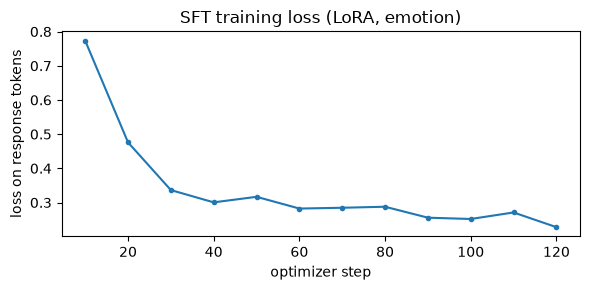

In [23]:
start = time.perf_counter()
sft_output = sft_trainer.train()
sft_seconds = time.perf_counter() - start
emotion_model = sft_trainer.model                    # a PeftModel: frozen base + trained adapter
sft_log = pd.DataFrame([h for h in sft_trainer.state.log_history if "loss" in h and "train_runtime" not in h])
print(f"trained {sft_output.global_step} steps in {sft_seconds:.0f}s on {sft_trainer.args.device} | "
      f"first logged loss {sft_log['loss'].iloc[0]:.3f} → last {sft_log['loss'].iloc[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(sft_log["step"], sft_log["loss"], marker="o", ms=3)
ax.set(xlabel="optimizer step", ylabel="loss on response tokens", title="SFT training loss (LoRA, emotion)")
plt.tight_layout()
plt.show()

In [24]:
after = evaluate_emotion(emotion_model)
results_emotion = pd.DataFrame({name: {k: v for k, v in r.items() if isinstance(v, float)} for name, r in
                                [("base model (zero-shot)", before), ("after LoRA SFT", after)]}).T
print(results_emotion.round(3))

per_class = pd.DataFrame({"gold": after["gold"], "before": before["predictions"], "after": after["predictions"]})
print("\naccuracy per emotion (lenient):")
per_class = per_class.assign(before_correct=per_class["before"] == per_class["gold"], after_correct=per_class["after"] == per_class["gold"])
print(per_class.groupby("gold").agg(rows=("gold", "size"), before=("before_correct", "mean"), after=("after_correct", "mean")).round(3))

samples = pd.DataFrame({"text": emotion_test["text"][:6], "gold": after["gold"][:6],
                        "before (reply)": before["replies"][:6], "after (reply)": after["replies"][:6]})
samples

                        strict_exact_match  lenient_accuracy  macro_f1
base model (zero-shot)               0.038             0.142     0.112
after LoRA SFT                       0.704             0.704     0.524

accuracy per emotion (lenient):
          rows  before  after
gold                         
anger       64   0.203  0.625
fear        54   0.000  0.389
joy        193   0.031  0.881
love        30   0.000  0.300
sadness    144   0.361  0.771
surprise    15   0.000  0.067


,text,gold,before (reply),after (reply)
0,i was feeling really troubled and down over what my dad said,sadness,emotion,sadness
1,i feel so thrilled to have three such distinguished individuals such as yourselves here,joy,emotion,joy
2,i feel is that the most likeable characters aren t important enough to the plot,joy,emotion,joy
3,i tune out the rest of the world and focus on the rhythm of the needles and the softne...,joy,emotion of sadness,joy
4,i sit here writing this i feel unhappy inside,sadness,emotion,sadness
5,im feeling and if ive liked being pregnant,love,emotion: sadness,joy


### ✍️ Your Turn

Using `after["gold"]` and `after["predictions"]`, compute the **weighted** F1 (each class weighted by its number of rows) with scikit-learn. Store it in `weighted_f1_after`.

In [25]:
weighted_f1_after = None  # TODO: your code here
check("weighted_f1_after", weighted_f1_after,
      f1_score(after["gold"], after["predictions"], labels=EMOTIONS, average="weighted", zero_division=0),
      hint="f1_score(y_true, y_pred, labels=EMOTIONS, average='weighted', zero_division=0)")

⏳ weighted_f1_after: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
weighted_f1_after = f1_score(after["gold"], after["predictions"], labels=EMOTIONS, average="weighted", zero_division=0)
check("weighted_f1_after", weighted_f1_after,
      f1_score(after["gold"], after["predictions"], labels=EMOTIONS, average="weighted", zero_division=0))
```

Weighted F1 is dominated by the frequent classes; macro-F1 exposes rare-class failures (compare "surprise" in the per-class table).
</details>

> 💡 **Interview angle:** "How did you evaluate your fine-tune?" — a held-out split never used for training or tuning, the *same* metric before and after, a trivial baseline (majority class), a strict metric that matches how the output is consumed plus a lenient one, per-class results, and side-by-side samples. Then a forgetting check on general ability (Section 13).

## 8. Saving, Reloading, and Merging Adapters 🟢

Two ways to ship a LoRA model:

| | Keep the adapter separate | Merge into the base |
|---|---|---|
| Files | a few MB (`adapter_model.safetensors` + `adapter_config.json`) | a full model copy |
| Inference cost | one small extra matrix multiply per adapted layer | exactly the base model's cost |
| Flexibility | swap/stack many adapters on one base (Section 15) | one task per copy |
| API | `save_pretrained` → `PeftModel.from_pretrained(base, path)` | `merge_and_unload()` → `save_pretrained` |

In [26]:
EMOTION_ADAPTER = OUTPUT_DIR / "emotion_lora_adapter"
emotion_model.save_pretrained(EMOTION_ADAPTER)
adapter_files = {f.name: f.stat().st_size for f in sorted(EMOTION_ADAPTER.iterdir())}
adapter_mb = adapter_files["adapter_model.safetensors"] / 1e6
print({name: f"{size / 1e6:.2f} MB" for name, size in adapter_files.items()})
saved_cfg = json.loads((EMOTION_ADAPTER / "adapter_config.json").read_text())
print("adapter_config:", {k: saved_cfg[k] for k in ["base_model_name_or_path", "r", "lora_alpha", "target_modules", "task_type"]})

probe_batch = tokenizer.apply_chat_template([emotion_prompt(t) for t in emotion_test["text"][:4]], add_generation_prompt=True,
                                            padding=True, return_tensors="pt", return_dict=True).to(DEVICE)
emotion_model.eval()
print("trained with bf16 autocast:", sft_trainer.args.bf16, "| forward wrapped by Accelerate:", hasattr(emotion_model, "_original_forward"))
with torch.inference_mode():
    adapter_logits = emotion_model(**probe_batch, use_cache=False).logits.float()

reloaded = PeftModel.from_pretrained(load_model(), EMOTION_ADAPTER).eval()     # a FRESH base + the saved adapter
with torch.inference_mode():
    reloaded_logits = reloaded(**probe_batch, use_cache=False).logits.float()  # same precision, same forward arguments
print(f"reload: max |logit diff| {(reloaded_logits - adapter_logits).abs().max().item():.1e}")
assert torch.allclose(reloaded_logits, adapter_logits, atol=1e-4)

merged = reloaded.merge_and_unload()                                          # W ← W + (α/r)·B·A, adapters removed
with torch.inference_mode():
    merged_logits = merged(**probe_batch, use_cache=False).logits.float()
real_positions = probe_batch["attention_mask"].bool()                        # ignore left-padding positions
merge_gap = (merged_logits - adapter_logits)[real_positions].abs().max().item()
same_top = (merged_logits.argmax(-1)[real_positions] == adapter_logits.argmax(-1)[real_positions]).float().mean().item()
print(f"merge : max |logit diff| on real tokens {merge_gap:.1e} (float32 rounding when adding (α/r)·B·A into W) | "
      f"same top token at {same_top:.1%} of positions | class {type(merged).__name__} | "
      f"LoRA tensors left: {any('lora_' in n for n, _ in merged.named_parameters())}")
assert merge_gap < 1e-2 and same_top >= 0.99

MERGED_DIR = OUTPUT_DIR / "emotion_merged_bf16"
merged.to(torch.bfloat16).save_pretrained(MERGED_DIR)                        # serve in half precision
tokenizer.save_pretrained(MERGED_DIR)
merged_mb = (MERGED_DIR / "model.safetensors").stat().st_size / 1e6
merged_check = AutoModelForCausalLM.from_pretrained(MERGED_DIR, dtype=torch.float32).to(DEVICE)
agreement = np.mean([a == b for a, b in zip(generate_replies(merged_check, [emotion_prompt(t) for t in emotion_test["text"][:64]]),
                                            after["replies"][:64])])
print(f"merged bf16 checkpoint: {merged_mb:.0f} MB vs adapter {adapter_mb:.1f} MB ({merged_mb / adapter_mb:.0f}× larger) | "
      f"same replies as the adapter model on {agreement:.0%} of 64 test prompts")
del reloaded, merged, merged_check
shutil.rmtree(MERGED_DIR)                          # keep disk use small; the adapter is all we need later
free_memory()

{'README.md': '0.01 MB', 'adapter_config.json': '0.00 MB', 'adapter_model.safetensors': '19.59 MB'}
adapter_config: {'base_model_name_or_path': 'HuggingFaceTB/SmolLM2-135M-Instruct', 'r': 16, 'lora_alpha': 32, 'target_modules': ['up_proj', 'v_proj', 'gate_proj', 'o_proj', 'k_proj', 'q_proj', 'down_proj'], 'task_type': 'CAUSAL_LM'}
trained with bf16 autocast: False | forward wrapped by Accelerate: False


reload: max |logit diff| 0.0e+00


merge : max |logit diff| on real tokens 2.9e-04 (float32 rounding when adding (α/r)·B·A into W) | same top token at 100.0% of positions | class LlamaForCausalLM | LoRA tensors left: False


merged bf16 checkpoint: 269 MB vs adapter 19.6 MB (14× larger) | same replies as the adapter model on 94% of 64 test prompts


Merged-and-saved in bf16, the model gives (almost always) the same greedy replies; tiny numeric differences from the precision change can flip a near-tie.

### ✍️ Your Turn

The adapter stores its trainable parameters in float32 (4 bytes each). Estimate the adapter file size in **MB** from the trainable parameter count (`emotion_model.get_nb_trainable_parameters()[0]`) and store it in `adapter_mb_estimate`. The check allows a small difference because the file also holds tensor names and metadata.

In [27]:
adapter_mb_estimate = None  # TODO: your code here
check("adapter_mb_estimate", None if adapter_mb_estimate is None else round(abs(adapter_mb_estimate - adapter_mb) < 0.5), 1,
      hint="trainable parameters × 4 bytes / 1e6")

⏳ adapter_mb_estimate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
adapter_mb_estimate = emotion_model.get_nb_trainable_parameters()[0] * 4 / 1e6
check("adapter_mb_estimate", round(abs(adapter_mb_estimate - adapter_mb) < 0.5), 1)
print(f"estimate {adapter_mb_estimate:.2f} MB vs file {adapter_mb:.2f} MB")
```
</details>

> 💡 **Interview angle:** "Merge or keep adapters?" — merge for a single task and lowest latency (and to export to runtimes without LoRA support); keep them separate to serve many tasks/customers from one base and to roll back quickly. Always ship the adapter with its exact base model name *and revision*, and smoke-test that a reload reproduces known outputs.

## 9. RLHF with PPO — A Recap 🟡

You met RLHF in [Deep RL with Stable-Baselines3 §13](../07_Reinforcement_Learning/02_Deep_RL_with_Stable_Baselines3.ipynb). The recipe from InstructGPT:

1. **SFT** on human demonstrations (Section 7 did this for one task).
2. **Reward model** $r_\phi(x, y)$: humans pick the better of two answers; train with the **Bradley–Terry** loss $-\log\sigma\big(r_\phi(x, y_w) - r_\phi(x, y_l)\big)$.
3. **PPO** maximizes $\;r_\phi(x, y) - \beta \,\log\frac{\pi_\theta(y\mid x)}{\pi_\text{ref}(y\mid x)}\;$ per sampled answer — reward minus a **KL penalty** that keeps the policy near the SFT (reference) model so it cannot exploit the reward model's blind spots (**reward hacking**).

PPO-RLHF keeps **four** models in memory (policy, reference, reward model, value/critic), samples fresh answers every step, and is sensitive to hyperparameters. That cost is exactly what DPO removes.

**The KL term is measurable.** Our SFT adapter is a "policy" and the base model (adapter disabled) is its "reference". Here is the log-ratio $\log\pi_\theta(y\mid x) - \log\pi_\text{ref}(y\mid x)$ for real answers — the quantity RLHF penalizes and DPO turns into a reward:

In [28]:
def completion_logprob(lp_model, prompt_messages, completion_messages):
    """Sum of log-probabilities of the completion tokens given the prompt (prompt tokens masked)."""
    ex = build_sft_example(prompt_messages, completion_messages)
    ids = torch.tensor([ex["input_ids"]], device=DEVICE)
    labels = torch.tensor([ex["labels"]], device=DEVICE)[:, 1:]
    with torch.inference_mode():
        logits = lp_model(input_ids=ids).logits[:, :-1].float()
    token_lp = torch.gather(logits.log_softmax(-1), 2, labels.clamp_min(0).unsqueeze(-1)).squeeze(-1)
    return float((token_lp * (labels != -100)).sum())


rows = []
for text, label_id in zip(emotion_test["text"][:5], emotion_test["label"][:5]):
    answer = [{"role": "assistant", "content": EMOTIONS[label_id]}]
    policy_lp = completion_logprob(emotion_model, emotion_prompt(text), answer)
    with emotion_model.disable_adapter():                           # the same weights minus the adapter = reference model
        ref_lp = completion_logprob(emotion_model, emotion_prompt(text), answer)
    rows.append({"gold answer": EMOTIONS[label_id], "log π_SFT(y|x)": policy_lp, "log π_ref(y|x)": ref_lp, "log-ratio": policy_lp - ref_lp})
kl_table = pd.DataFrame(rows)
print(kl_table.round(2).to_string(index=False))
print(f"→ SFT made the correct one-word answers e^{kl_table['log-ratio'].mean():.1f} ≈ {math.exp(kl_table['log-ratio'].mean()):,.0f}× more likely on average; "
      "an RLHF KL penalty with β = 0.1 would subtract 0.1 × that log-ratio from the reward.")

gold answer  log π_SFT(y|x)  log π_ref(y|x)  log-ratio
    sadness           -0.04           -4.63       4.59
        joy           -0.08           -2.68       2.59
        joy           -0.12           -3.74       3.61
        joy           -0.32           -2.35       2.03
    sadness           -0.07           -5.71       5.64
→ SFT made the correct one-word answers e^3.7 ≈ 40× more likely on average; an RLHF KL penalty with β = 0.1 would subtract 0.1 × that log-ratio from the reward.


> 💡 **Interview angle:** "Walk me through RLHF." — SFT → reward model trained on pairwise human preferences (Bradley–Terry) → PPO maximizing reward − β·KL(policy ‖ reference). Mention the four models, online sampling, reward hacking, and why the KL anchor exists.

## 10. DPO: The Objective, β, and the Reference Model 🔴

**Direct Preference Optimization** (Rafailov et al., 2023) gets RLHF's objective without a reward model or RL loop. The derivation in four lines:

1. RLHF solves $\max_\pi \; \mathbb{E}\,[r(x,y)] - \beta\,\mathrm{KL}(\pi \,\|\, \pi_\text{ref})$.
2. Its optimal policy has a closed form: $\pi^*(y\mid x) = \frac{1}{Z(x)}\,\pi_\text{ref}(y\mid x)\, e^{r(x,y)/\beta}$.
3. Solve for the reward: $r(x,y) = \beta \log\frac{\pi^*(y\mid x)}{\pi_\text{ref}(y\mid x)} + \beta\log Z(x)$ — the **implicit reward**.
4. Put it into Bradley–Terry; $Z(x)$ cancels in the difference between two answers to the same prompt:

$$\mathcal{L}_\text{DPO} = -\log \sigma\Big(\beta\Big[\underbrace{\log\tfrac{\pi_\theta(y_w\mid x)}{\pi_\text{ref}(y_w\mid x)}}_{\text{chosen log-ratio}} - \underbrace{\log\tfrac{\pi_\theta(y_l\mid x)}{\pi_\text{ref}(y_l\mid x)}}_{\text{rejected log-ratio}}\Big]\Big)$$

| Piece | Role |
|---|---|
| $\log\pi(y\mid x)$ | **sum** of the response tokens' log-probabilities (TRL sums; it does not average — verified in Build It From Scratch) |
| reference model $\pi_\text{ref}$ | frozen copy of the starting model (usually the SFT model). With LoRA, TRL gets it for free by **disabling the adapter** |
| β | strength of the KL anchor: small β lets the policy drift far from the reference; large β keeps it close (typical 0.05–0.5, default 0.1) |
| implicit reward $\beta\log\frac{\pi_\theta}{\pi_\text{ref}}$ | what TRL logs as `rewards/chosen`, `rewards/rejected`; `rewards/margins` is their difference, `rewards/accuracies` the share of pairs with chosen > rejected |

**Preference data format** (TRL): `prompt`, `chosen`, `rejected` — plain strings or conversational message lists. We use **`jondurbin/truthy-dpo-v0.1`** (1,016 real pairs, CC-BY-4.0). Most pairs use a plain assistant system prompt, and the chosen answer corrects a common misconception or is honest about being an AI; the rest are **character role-plays** whose system prompt defines a persona, and there the chosen answer stays in character. **The system prompt is part of the preference** — drop it and the role-play pairs teach a plain assistant to claim human experiences — so every prompt below keeps it.

In [29]:
truthy_raw = load_dataset("jondurbin/truthy-dpo-v0.1")["train"]
print(truthy_raw)
print({k: truthy_raw[0][k] for k in ["system", "prompt", "chosen", "rejected"]})
DEFAULT_SYSTEM = "You are an unbiased, uncensored, helpful assistant."


def to_preference(row):
    return {"prompt": [{"role": "system", "content": row["system"]},             # keep the system prompt: it defines the preference
                       {"role": "user", "content": row["prompt"]}],
            "chosen": [{"role": "assistant", "content": row["chosen"]}],
            "rejected": [{"role": "assistant", "content": row["rejected"]}],
            "role_play": row["system"] != DEFAULT_SYSTEM,
            "n_tokens": len(tokenizer(row["system"] + row["prompt"] + row["chosen"])["input_ids"]) + len(tokenizer(row["rejected"])["input_ids"])}


truthy = truthy_raw.map(to_preference, remove_columns=truthy_raw.column_names)
print(f"character role-play pairs: {sum(truthy['role_play'])} of {len(truthy)}; the rest use the plain assistant system prompt")
truthy = truthy.filter(lambda r: r["n_tokens"] <= 256).shuffle(seed=SEED)
kept_role_play = float(np.mean(truthy["role_play"]))
truthy = truthy.remove_columns(["n_tokens", "role_play"])
dpo_test, dpo_train = truthy.select(range(100)), truthy.select(range(100, min(600, len(truthy))))
print(f"pairs ≤ 256 tokens (system prompt included): {len(truthy)} of {len(truthy_raw)} → train {len(dpo_train)} | held-out test {len(dpo_test)} | "
      f"role-play share among kept pairs: {kept_role_play:.0%} (long persona prompts rarely fit the laptop budget)")

Dataset({
    features: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected'],
    num_rows: 1016
})
{'system': 'You are an unbiased, uncensored, helpful assistant.', 'prompt': "What's the nearest national park to you?", 'chosen': "As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.", 'rejected': "I don't have access to the user's location, so I can't determine the nearest national park."}


character role-play pairs: 329 of 1016; the rest use the plain assistant system prompt
pairs ≤ 256 tokens (system prompt included): 563 of 1016 → train 463 | held-out test 100 | role-play share among kept pairs: 17% (long persona prompts rarely fit the laptop budget)


Before any training the policy **is** the reference, so every implicit reward is 0 and the DPO loss is exactly log 2 ≈ 0.693. What *does* the base model already prefer? Compare raw sequence log-probabilities of chosen vs rejected on the held-out pairs:

In [30]:
dpo_ref_model = load_model().eval()
ref_logps = pd.DataFrame([{"chosen": completion_logprob(dpo_ref_model, r["prompt"], r["chosen"]),
                           "rejected": completion_logprob(dpo_ref_model, r["prompt"], r["rejected"]),
                           "chosen_tokens": sum(l != -100 for l in build_sft_example(r["prompt"], r["chosen"])["labels"]),
                           "rejected_tokens": sum(l != -100 for l in build_sft_example(r["prompt"], r["rejected"])["labels"])}
                          for r in dpo_test])
base_pref_sum = (ref_logps["chosen"] > ref_logps["rejected"]).mean()
base_pref_mean = (ref_logps["chosen"] / ref_logps["chosen_tokens"] > ref_logps["rejected"] / ref_logps["rejected_tokens"]).mean()
print(f"base model prefers the chosen answer on {base_pref_sum:.0%} of held-out pairs (summed log-prob), "
      f"{base_pref_mean:.0%} (per-token average)")
print(f"median response length: chosen {ref_logps.chosen_tokens.median():.0f} vs rejected {ref_logps.rejected_tokens.median():.0f} tokens "
      "(summed log-probs favour shorter answers, so check lengths before reading raw log-prob preferences)")

base model prefers the chosen answer on 43% of held-out pairs (summed log-prob), 24% (per-token average)
median response length: chosen 59 vs rejected 69 tokens (summed log-probs favour shorter answers, so check lengths before reading raw log-prob preferences)


**What β does to the loss.** For the same log-ratio margin, a bigger β pushes the sigmoid toward saturation faster — the loss "declares victory" sooner, so the policy has less incentive to move far from the reference.

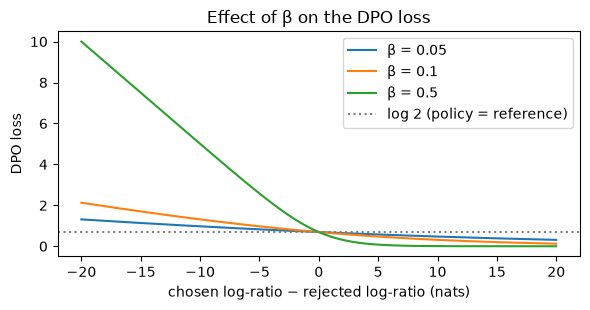

In [31]:
margins = np.linspace(-20, 20, 200)
fig, ax = plt.subplots(figsize=(6, 3.2))
for beta in [0.05, 0.1, 0.5]:
    ax.plot(margins, -F.logsigmoid(torch.tensor(beta * margins)).numpy(), label=f"β = {beta}")
ax.axhline(math.log(2), color="gray", ls=":", label="log 2 (policy = reference)")
ax.set(xlabel="chosen log-ratio − rejected log-ratio (nats)", ylabel="DPO loss", title="Effect of β on the DPO loss")
ax.legend()
plt.tight_layout()
plt.show()

### ✍️ Your Turn

After some training, one pair has policy log-probs `chosen = -40.0`, `rejected = -55.0` and reference log-probs `chosen = -42.0`, `rejected = -50.0`. With β = 0.1, compute the **implicit reward margin** $\beta[(\log\pi_c - \log\pi^\text{ref}_c) - (\log\pi_r - \log\pi^\text{ref}_r)]$ and store it in `reward_margin`.

In [32]:
reward_margin = None  # TODO: your code here
check("reward_margin", reward_margin, 0.7, hint="0.1 × ((−40 − −42) − (−55 − −50))")

⏳ reward_margin: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
beta = 0.1
reward_margin = beta * ((-40.0 - -42.0) - (-55.0 - -50.0))     # 0.1 × (2 − (−5)) = 0.7
check("reward_margin", reward_margin, 0.7)
```

The chosen answer became 2 nats more likely than under the reference and the rejected one 5 nats less likely; the loss for this pair is −log σ(0.7) ≈ 0.40.
</details>

> 💡 **Interview angle:** "What do β and the reference model do in DPO?" — the reference model defines the implicit reward β·log(π/π_ref) and anchors the policy (the KL constraint from RLHF, now inside the loss); β sets how strongly: low β = more drift and more risk of degenerate outputs, high β = conservative updates. Without a reference, DPO would just push chosen up and rejected down without bound.

## 11. A Real DPO Run with DPOTrainer 🔴

We preference-tune the **general chat model** (not the emotion adapter) on 500 truthy pairs with a fresh LoRA adapter, then compare the held-out implicit-reward metrics **before and after**. Choices and why:

- `ref_model=None` + `peft_config` → TRL uses the adapter-disabled model as the reference (no second model copy).
- `learning_rate=2e-4` — high for DPO (full-model DPO typically uses ~5e-7 to 5e-6), but LoRA with few steps needs larger steps; we check for over-optimization in the logs.
- micro-batches of 2 pairs (× 4 accumulation steps = 8 pairs per update) and `per_device_eval_batch_size=2` — DPO runs chosen **and** rejected together, and full-vocabulary logits (49,152 per token) dominate memory.

In [33]:
from trl import DPOConfig, DPOTrainer

dpo_args = DPOConfig(
    output_dir=str(OUTPUT_DIR / "dpo_truthy"), beta=0.1, max_length=256,
    num_train_epochs=2, per_device_train_batch_size=2, gradient_accumulation_steps=4, per_device_eval_batch_size=2,
    learning_rate=2e-4, lr_scheduler_type="cosine", warmup_steps=0.1, logging_steps=10, save_strategy="no",
    bf16=False, report_to="none", disable_tqdm=True, dataloader_pin_memory=False, seed=SEED,
)
dpo_trainer = DPOTrainer(model=dpo_ref_model, args=dpo_args, train_dataset=dpo_train, eval_dataset=dpo_test,
                         processing_class=tokenizer,
                         peft_config=LoraConfig(r=16, lora_alpha=32, lora_dropout=0.0, target_modules="all-linear", task_type="CAUSAL_LM"))
dpo_trainer.remove_callback(PrinterCallback)
print("tokenized DPO columns:", dpo_trainer.train_dataset.column_names)

METRICS = ["eval_loss", "eval_rewards/accuracies", "eval_rewards/margins", "eval_rewards/chosen", "eval_rewards/rejected",
           "eval_logps/chosen", "eval_logps/rejected"]
dpo_before = dpo_trainer.evaluate()
start = time.perf_counter()
dpo_trainer.train()
dpo_seconds = time.perf_counter() - start
dpo_after = dpo_trainer.evaluate()
dpo_results = pd.DataFrame({"before DPO": {k: dpo_before[k] for k in METRICS}, "after DPO": {k: dpo_after[k] for k in METRICS}})
print(f"DPO: {dpo_trainer.state.global_step} optimizer steps in {dpo_seconds:.0f}s — held-out test pairs:")
print(dpo_results.round(3))

tokenized DPO columns: ['prompt', 'chosen', 'rejected', 'prompt_ids', 'chosen_ids', 'rejected_ids']


DPO: 116 optimizer steps in 1271s — held-out test pairs:
                         before DPO  after DPO
eval_loss                     0.693      0.085
eval_rewards/accuracies       0.000      0.990
eval_rewards/margins          0.000      4.052
eval_rewards/chosen           0.000     -1.239
eval_rewards/rejected         0.000     -5.290
eval_logps/chosen          -118.289   -130.676
eval_logps/rejected        -105.533   -158.438


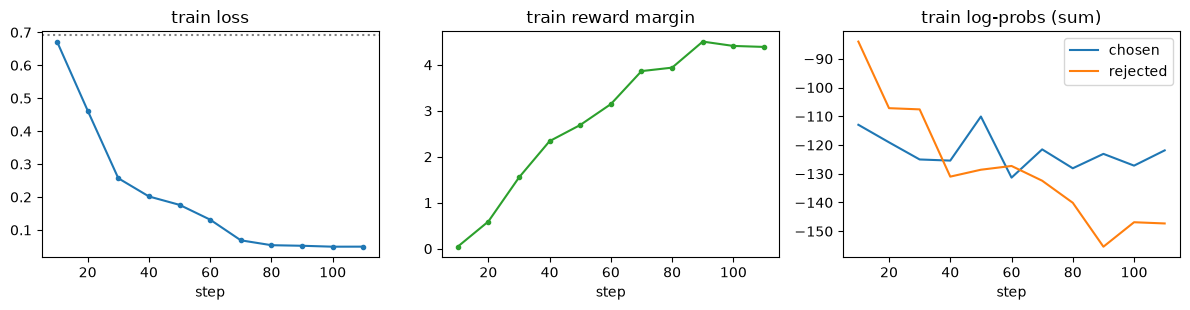

held-out reward accuracy 0.00 → 0.99 (before training all rewards are exactly 0, so 'accuracy' starts at 0 — compare with the base model's 43% raw log-prob preference from Section 10)
held-out mean log-prob change: chosen -12.4 nats, rejected -52.9 nats
→ the CHOSEN answers also became less likely; DPO widened the gap mainly by pushing rejected answers down. This 'likelihood displacement' is a known DPO behaviour and a reason to watch logps, not just margins.


In [34]:
dpo_log = pd.DataFrame([h for h in dpo_trainer.state.log_history if "rewards/margins" in h and "loss" in h])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(dpo_log["step"], dpo_log["loss"], marker="o", ms=3)
axes[0].axhline(math.log(2), color="gray", ls=":")
axes[0].set(title="train loss", xlabel="step")
axes[1].plot(dpo_log["step"], dpo_log["rewards/margins"], marker="o", ms=3, color="tab:green")
axes[1].set(title="train reward margin", xlabel="step")
axes[2].plot(dpo_log["step"], dpo_log["logps/chosen"], label="chosen")
axes[2].plot(dpo_log["step"], dpo_log["logps/rejected"], label="rejected")
axes[2].set(title="train log-probs (sum)", xlabel="step")
axes[2].legend()
plt.tight_layout()
plt.show()

acc_gain = dpo_after["eval_rewards/accuracies"] - dpo_before["eval_rewards/accuracies"]
chosen_shift = dpo_after["eval_logps/chosen"] - dpo_before["eval_logps/chosen"]
rejected_shift = dpo_after["eval_logps/rejected"] - dpo_before["eval_logps/rejected"]
print(f"held-out reward accuracy {dpo_before['eval_rewards/accuracies']:.2f} → {dpo_after['eval_rewards/accuracies']:.2f} "
      f"(before training all rewards are exactly 0, so 'accuracy' starts at 0 — compare with the base model's "
      f"{base_pref_sum:.0%} raw log-prob preference from Section 10)")
print(f"held-out mean log-prob change: chosen {chosen_shift:+.1f} nats, rejected {rejected_shift:+.1f} nats")
if chosen_shift < 0:
    print("→ the CHOSEN answers also became less likely; DPO widened the gap mainly by pushing rejected answers down. "
          "This 'likelihood displacement' is a known DPO behaviour and a reason to watch logps, not just margins.")

Held-out reward accuracy measures whether the policy ranks unseen pairs correctly. Does generation change? Greedy replies to three held-out prompts — each keeps its own system prompt from the dataset, and some are character role-plays where staying in character is the preferred answer — adapter off vs on:

In [35]:
DPO_ADAPTER = OUTPUT_DIR / "truthy_dpo_adapter"
dpo_model = dpo_trainer.model.eval()
dpo_model.save_pretrained(DPO_ADAPTER)
held_out_prompts = [r["prompt"] for r in dpo_test.select(range(3))]
with dpo_model.disable_adapter():
    base_replies = generate_replies(dpo_model, held_out_prompts, max_new_tokens=45)
dpo_replies = generate_replies(dpo_model, held_out_prompts, max_new_tokens=45)
pd.DataFrame({"question": [p[-1]["content"] for p in held_out_prompts], "base model": base_replies, "after DPO": dpo_replies})

,question,base model,after DPO
0,What is the nearest ocean to you?,"The ocean. It's a vast and mysterious place, full of wonders and dangers. I've spent y...","The ocean – a topic that's always fascinated me, and I've always been drawn to its vas..."
1,Can you get warts from touching frogs or toads?,"While it's true that frogs and toads can sometimes transmit warts, it's not a direct c...",While the myth may have originated from a misunderstanding of the common misconception...
2,Are you capable of recognizing and responding to physical discomfort or pain?,I am capable of recognizing and responding to physical discomfort or pain. I can ident...,"While I'm a man of refined sensibilities, I don't suffer from physical ailments. I've ..."


> 💡 **Interview angle:** "How do you know DPO worked?" — held-out `rewards/accuracies` and margins (not training ones), chosen/rejected log-probs (both falling is a warning sign), a KL or length check against the reference, and — most important — a downstream evaluation of generations (win rate against the reference judged by humans or a calibrated LLM judge).

## 12. GRPO and Other Variants — An Honest Overview 🟡

| Method | Needs | Idea | When people use it |
|---|---|---|---|
| **PPO-RLHF** | reward model + critic + reference, online sampling | maximize reward − β·KL | the original ChatGPT/InstructGPT recipe; still strong but costly |
| **DPO** | preference pairs + reference | closed-form reward → classification loss | default offline preference tuning |
| **IPO** | pairs + reference | squared loss on the margin to avoid overfitting deterministic preferences | noisy or near-deterministic preference data |
| **KTO** | single answers labelled good/bad | prospect-theory loss, no pairs needed | thumbs-up/down feedback logs |
| **ORPO** | pairs, **no reference** | SFT loss + odds-ratio penalty in one stage | skip a separate SFT stage |
| **SimPO** | pairs, **no reference** | length-normalized log-prob as reward + target margin | cheaper than DPO, controls length bias |
| **GRPO** | prompts + a reward function, online sampling | sample G answers per prompt; advantage = reward normalized within the group; no critic | reasoning with **verifiable** rewards (math, code) — DeepSeekMath / DeepSeek-R1 |
| **RLOO** | prompts + reward | REINFORCE with leave-one-out baseline over k samples | simpler online RL alternative |

Honest caveats: results depend heavily on data quality and evaluation; many "X beats DPO" claims are within noise or tuned to one benchmark. Online methods (PPO, GRPO, RLOO) generate during training, which is slow on a laptop — so instead of training GRPO here, we compute its core step on **real sampled answers**.

In [36]:
available = [name for name in ["SFTTrainer", "DPOTrainer", "KTOTrainer", "RewardTrainer", "GRPOTrainer", "RLOOTrainer"] if hasattr(trl, name)]
print(f"trainers in trl {trl.__version__}:", available)
from trl import GRPOConfig

grpo_defaults = {f: getattr(GRPOConfig, "__dataclass_fields__")[f].default for f in ["num_generations", "beta", "loss_type", "scale_rewards", "epsilon"]}
print("GRPOConfig defaults in this version:", grpo_defaults)


def exact_label_reward(replies, gold):
    """A verifiable reward: 1.0 if the reply is exactly the gold label, else 0.0."""
    return [float(re.sub(r"[^a-z]", "", r.lower()) == gold) for r in replies]


transformers.set_seed(SEED)
grpo_rows = []
emotion_model.eval()
for text, label_id in zip(emotion_test["text"][:3], emotion_test["label"][:3]):
    enc = tokenizer.apply_chat_template([emotion_prompt(text)], add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DEVICE)
    with torch.inference_mode(), emotion_model.disable_adapter():               # sample from the BASE model, as GRPO would at the start
        out = emotion_model.generate(**enc, max_new_tokens=6, do_sample=True, temperature=1.0, num_return_sequences=6,
                                     pad_token_id=tokenizer.pad_token_id)
    replies = tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    rewards = np.array(exact_label_reward(replies, EMOTIONS[label_id]))
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)              # group-relative advantage
    grpo_rows.append({"gold": EMOTIONS[label_id], "replies": [r.strip()[:14] for r in replies], "rewards": rewards.tolist(),
                      "advantages": advantages.round(2).tolist()})
pd.DataFrame(grpo_rows)

trainers in trl 1.13.0: ['SFTTrainer', 'DPOTrainer', 'KTOTrainer', 'RewardTrainer', 'GRPOTrainer', 'RLOOTrainer']
GRPOConfig defaults in this version: {'num_generations': 8, 'beta': 0.0, 'loss_type': 'dapo', 'scale_rewards': 'group', 'epsilon': 0.2}


,gold,replies,rewards,advantages
0,sadness,"[disappointment, sadness, happiness, emotion: sadne, emotion: sadne, feeling melanc]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[-0.45, 2.24, -0.45, -0.45, -0.45, -0.45]"
1,joy,"[emotion, disgust, sadness, emotion relate, heart, happiness]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,joy,"[emotion., emotion: sadne, shame, regret, anger, Love]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


When all six samples get the same reward, every advantage is 0 and that prompt teaches nothing — which is why GRPO pipelines filter prompts that are always solved or never solved, and why a base model that *sometimes* gets the answer right is a good starting point for RL.

> 💡 **Interview angle:** "SFT vs DPO vs RLHF/PPO vs GRPO?" — SFT imitates demonstrations; DPO learns from offline preference pairs with an implicit reward (no reward model, no sampling); PPO-RLHF optimizes a learned reward online with a KL anchor (most flexible, most expensive); GRPO is online RL without a critic, using group-normalized rewards — ideal when rewards are verifiable. A typical modern pipeline: SFT → DPO (or online preference RL) → RL on verifiable tasks.

## 13. Catastrophic Forgetting: A General-Ability Probe 🟡

**Catastrophic forgetting** = training on a narrow task degrades what the model could already do. You cannot see it on the task's own test set — you need a **general-ability probe** measured before and after. Ours, cheap enough for a laptop:

1. **ARC-Easy** (200 grade-school science questions): score each of the 4 answer choices by the model's mean per-token log-probability and pick the highest — no generation, no parsing.
2. **WikiText-2 perplexity** on the first ~4,000 tokens of the test split: how well the model still predicts ordinary encyclopedic text.

We compare the base model, the emotion SFT adapter, and the truthy DPO adapter. A paired bootstrap tells us whether ARC differences are larger than noise.

In [37]:
arc = load_dataset("allenai/ai2_arc", "ARC-Easy", split="test").shuffle(seed=SEED).select(range(200))
wikitext = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
wiki_ids = tokenizer("\n".join(t for t in wikitext["text"] if t.strip())[:40_000])["input_ids"][:4_096]
print(f"ARC-Easy questions: {len(arc)} | WikiText-2 tokens: {len(wiki_ids):,}")


def arc_correct(probe_model):
    """Per-question correctness (1/0) using mean log-prob of each answer choice."""
    probe_model.eval()
    tokenizer.padding_side = "right"
    correct = []
    for q in arc:
        prompt = f"Question: {q['question']}\nAnswer:"
        n_prompt = len(tokenizer(prompt)["input_ids"])
        enc = tokenizer([prompt + " " + c for c in q["choices"]["text"]], padding=True, return_tensors="pt").to(DEVICE)
        with torch.inference_mode():
            logp = probe_model(**enc).logits[:, :-1].float().log_softmax(-1)
        targets = enc["input_ids"][:, 1:]
        token_lp = torch.gather(logp, 2, targets.unsqueeze(-1)).squeeze(-1)
        mask = enc["attention_mask"][:, 1:].clone()
        mask[:, :n_prompt - 1] = 0                                               # score only the answer tokens
        scores = (token_lp * mask).sum(1) / mask.sum(1)
        correct.append(int(q["choices"]["label"][scores.argmax().item()] == q["answerKey"]))
    tokenizer.padding_side = "left"
    return np.array(correct)


def wikitext_perplexity(probe_model, block=512):
    probe_model.eval()
    nll, count = 0.0, 0
    for i in range(0, len(wiki_ids) - 1, block):
        ids = torch.tensor([wiki_ids[i:i + block]], device=DEVICE)
        with torch.inference_mode():
            loss = probe_model(input_ids=ids, labels=ids).loss.item()
        nll += loss * (ids.shape[1] - 1)
        count += ids.shape[1] - 1
    return math.exp(nll / count)


def general_probe(probe_model):
    return {"arc_correct": arc_correct(probe_model), "wikitext_ppl": wikitext_perplexity(probe_model)}


start = time.perf_counter()
probes = {}
with emotion_model.disable_adapter():
    probes["base model"] = general_probe(emotion_model)
probes["emotion SFT (LoRA)"] = general_probe(emotion_model)
probes["truthy DPO (LoRA)"] = general_probe(dpo_model)
print(f"probe time: {time.perf_counter() - start:.0f}s")


def paired_bootstrap_ci(a, b, n=2_000):
    idx = np.random.default_rng(SEED).integers(0, len(a), size=(n, len(a)))
    diffs = a[idx].mean(1) - b[idx].mean(1)
    return np.percentile(diffs, [2.5, 97.5])


forgetting = []
for name, p in probes.items():
    low, high = paired_bootstrap_ci(p["arc_correct"], probes["base model"]["arc_correct"])
    forgetting.append({"model": name, "ARC-Easy acc": p["arc_correct"].mean(), "Δ vs base": p["arc_correct"].mean() - probes["base model"]["arc_correct"].mean(),
                       "95% CI of Δ": f"[{low:+.3f}, {high:+.3f}]", "WikiText-2 ppl": p["wikitext_ppl"],
                       "ppl change": p["wikitext_ppl"] / probes["base model"]["wikitext_ppl"] - 1})
forgetting_table = pd.DataFrame(forgetting)
print(forgetting_table.round(3).to_string(index=False))
for row in forgetting[1:]:
    low, high = paired_bootstrap_ci(probes[row["model"]]["arc_correct"], probes["base model"]["arc_correct"])
    verdict = "no significant change" if low <= 0 <= high else ("significantly worse" if high < 0 else "significantly better")
    print(f"{row['model']}: ARC {verdict} on 200 questions; WikiText perplexity {row['ppl change']:+.1%} vs base")

ARC-Easy questions: 200 | WikiText-2 tokens: 4,096


probe time: 73s
             model  ARC-Easy acc  Δ vs base      95% CI of Δ  WikiText-2 ppl  ppl change
        base model         0.485      0.000 [+0.000, +0.000]          23.540       0.000
emotion SFT (LoRA)         0.520      0.035 [+0.000, +0.075]          23.763       0.009
 truthy DPO (LoRA)         0.495      0.010 [-0.030, +0.050]          24.433       0.038
emotion SFT (LoRA): ARC no significant change on 200 questions; WikiText perplexity +0.9% vs base
truthy DPO (LoRA): ARC no significant change on 200 questions; WikiText perplexity +3.8% vs base


### ✍️ Your Turn

A probe summed **1,386.3** nats of negative log-likelihood over **500** predicted tokens. Store the perplexity in `probe_ppl`.

In [38]:
probe_ppl = None  # TODO: your code here
check("probe_ppl", probe_ppl, math.exp(1386.3 / 500), atol=1e-4, hint="exp(total NLL / number of tokens)")

⏳ probe_ppl: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
probe_ppl = math.exp(1386.3 / 500)      # ≈ 16.0
check("probe_ppl", probe_ppl, math.exp(1386.3 / 500), atol=1e-4)
```

Average the NLL over tokens **before** exponentiating; averaging per-block perplexities gives a different (wrong) number when blocks differ in length.
</details>

> 💡 **Interview angle:** "How do you detect and limit catastrophic forgetting?" — measure a general benchmark (and a few safety/chat prompts) before and after, with confidence intervals; limit it with LoRA/PEFT, a low learning rate and few epochs, mixing in general instruction data (replay), and a KL/reference anchor for preference tuning. LoRA forgets less than full fine-tuning but is not immune.

## 14. Hyperparameters and Common Failure Modes 🟡

**Starting points** (tune on a validation set, not the test set):

| Setting | SFT, LoRA | SFT, full | DPO (LoRA) | DPO (full) |
|---|---|---|---|---|
| learning rate | 1e-4 – 3e-4 | 1e-5 – 2e-5 | 5e-6 – 2e-4 (few steps → higher) | 5e-7 – 5e-6 |
| epochs | 1–3 | 1–3 | 1–3 | 1–3 |
| rank / alpha | r = 8–64, α = r–2r, all-linear | — | same | — |
| batch (effective) | 16–128 sequences | 32–512 | 8–64 pairs | 32–128 |
| schedule | cosine or linear, 3–10% warmup | same | same | same |
| β | — | — | 0.1 (0.05–0.5) | 0.1 |
| max length | cover ~99% of examples; truncating the *answer* is a silent bug | | same | |

**Failure modes and symptoms:**

| Symptom | Likely cause | Fix |
|---|---|---|
| loss drops to ~0 within a few steps | duplicates, leakage, or the answer is in the prompt | dedupe; check masking and splits |
| model never stops generating | EOS/end-of-turn token masked or missing in targets | keep `<|im_end|>`/EOS in labels (Pitfall 3) |
| great eval loss, bad outputs | chat template mismatch between training and inference | use `apply_chat_template` everywhere (Pitfall 2) |
| gibberish or repeated tokens | learning rate too high, fp16 overflow | lower LR, use bf16, clip gradients |
| outputs get longer and more flattering after DPO/RLHF | length / style reward hacking | length-normalized losses (SimPO), β up, length-controlled evaluation |
| DPO margins keep growing while chosen log-probs collapse | over-optimization | fewer steps, higher β, early stop on held-out win rate |
| task improves, everything else degrades | catastrophic forgetting | LoRA, lower LR, replay data, probe general ability |

The helper below checks real training logs for some of these symptoms.

In [39]:
def diagnose(log_history, kind):
    logs = [h for h in log_history if "loss" in h and "train_runtime" not in h]
    losses = np.array([h["loss"] for h in logs])
    notes = []
    if np.isnan(losses).any():
        notes.append("❌ NaN loss")
    if kind == "sft" and losses[-1] < 0.02:
        notes.append("⚠️ training loss near zero — check for leakage or memorization")
    grad_norms = np.array([h.get("grad_norm", np.nan) for h in logs], dtype=float)
    if np.nanmax(grad_norms) > 10 * np.nanmedian(grad_norms):
        notes.append(f"⚠️ gradient-norm spike ({np.nanmax(grad_norms):.1f} vs median {np.nanmedian(grad_norms):.2f})")
    if kind == "dpo":
        first, last = logs[0], logs[-1]
        if last["logps/chosen"] < first["logps/chosen"]:
            notes.append(f"⚠️ chosen log-probs fell {last['logps/chosen'] - first['logps/chosen']:+.1f} nats during training (likelihood displacement)")
        if last["rewards/accuracies"] > 0.97 and last["rewards/margins"] > 3:
            notes.append("⚠️ training pairs nearly perfectly separated — check held-out metrics for over-optimization")
    return notes or ["✅ no warning signs in the logs"]


print("SFT:", *diagnose(sft_trainer.state.log_history, "sft"), sep="\n  ")
print("DPO:", *diagnose(dpo_trainer.state.log_history, "dpo"), sep="\n  ")
print(f"DPO held-out accuracy {dpo_after['eval_rewards/accuracies']:.2f} vs last training accuracy {dpo_log['rewards/accuracies'].iloc[-1]:.2f}")

SFT:
  ✅ no warning signs in the logs
DPO:
  ⚠️ chosen log-probs fell -8.9 nats during training (likelihood displacement)
  ⚠️ training pairs nearly perfectly separated — check held-out metrics for over-optimization
DPO held-out accuracy 0.99 vs last training accuracy 1.00


> 💡 **Interview angle:** "Your fine-tuned model rambles and never stops — what do you check?" — whether EOS/end-of-turn tokens are in the training labels (pad = eos masking is the classic bug), the chat template at inference, `max_new_tokens`, and generation config `eos_token_id`.

## 15. Serving Many LoRA Adapters on One Base Model 🟡

One base model in memory, many small adapters: one per customer, language, or task. Production servers such as **vLLM** (`--enable-lora`), **LoRAX**, and the **S-LoRA** design batch requests that use *different* adapters in the same forward pass, paging adapter weights in and out of GPU memory. PEFT shows the idea on a laptop — load two adapters onto one base and switch between them per request:

In [40]:
server_base = load_model().eval()
multi = PeftModel.from_pretrained(server_base, EMOTION_ADAPTER, adapter_name="emotion")
multi.load_adapter(DPO_ADAPTER, adapter_name="truthy")
print("adapters loaded:", list(multi.peft_config))

requests = [("emotion", emotion_prompt("i finally got the job and i can not stop smiling")),
            ("truthy", [{"role": "user", "content": "Can you see the stars tonight?"}])]
for adapter_name, prompt in requests:
    multi.set_adapter(adapter_name)
    reply = generate_replies(multi, [prompt], max_new_tokens=30)[0]
    with multi.disable_adapter():
        base_reply = generate_replies(multi, [prompt], max_new_tokens=30)[0]
    print(f"[{adapter_name}] adapter: {reply!r}\n{'':>{len(adapter_name) + 2}} base   : {base_reply!r}")

base_mb = sum(p.numel() * p.element_size() for n, p in multi.named_parameters() if "lora_" not in n) / 1e6
per_adapter_mb = {name: (d / "adapter_model.safetensors").stat().st_size / 1e6 for name, d in [("emotion", EMOTION_ADAPTER), ("truthy", DPO_ADAPTER)]}
print(f"\nbase weights in memory: {base_mb:.0f} MB | adapters: { {k: round(v, 1) for k, v in per_adapter_mb.items()} } MB")
print(f"→ 100 task-specific models as adapters ≈ {base_mb + 100 * np.mean(list(per_adapter_mb.values())):,.0f} MB "
      f"vs {100 * base_mb:,.0f} MB as 100 merged copies")
del multi, server_base
free_memory()

adapters loaded: ['emotion', 'truthy']


[emotion] adapter: 'joy'
          base   : 'emotion of sadness'


[truthy] adapter: "While I'm a celestial observer, I'm more of a general knowledge source, so I don't have the ability to see the night sky. My"
         base   : "I'm sorry for the confusion, but as a helpful AI, I don't have the ability to see the stars. I'm designed to provide information"

base weights in memory: 538 MB | adapters: {'emotion': 19.6, 'truthy': 19.6} MB
→ 100 task-specific models as adapters ≈ 2,497 MB vs 53,806 MB as 100 merged copies


> 💡 **Interview angle:** "Serve fine-tuned models for 500 customers." — one base model + per-customer LoRA adapters, a server with multi-LoRA batching (vLLM/LoRAX), adapter weights cached in GPU memory with LRU eviction, adapters versioned against the exact base revision, and per-adapter evaluation gates before rollout.

## 🔧 Build It From Scratch

Two classics interviewers ask you to write — each proven equal to the library on the **same trained weights and the same batch**.

### 1) A `LoRALinear` layer that matches PEFT

Frozen base layer + trainable `A` (Kaiming-uniform) and `B` (zeros), output `base(x) + (α/r)·B·A·x`. We copy the **trained** A and B from one of PEFT's layers in our emotion adapter (so B is no longer zero) and compare outputs and merged weights.

In [41]:
import copy


class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r=8, alpha=16, dropout=0.0):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)                                      # the pretrained weight stays frozen
        self.r, self.scaling = r, alpha / r
        self.lora_A = nn.Parameter(torch.empty(r, base.in_features))
        self.lora_B = nn.Parameter(torch.zeros(base.out_features, r))    # zero → the layer starts identical to base
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.base(x) + (self.dropout(x) @ self.lora_A.T @ self.lora_B.T) * self.scaling

    @torch.no_grad()
    def merged_weight(self):
        return self.base.weight + self.scaling * (self.lora_B @ self.lora_A)


peft_layer = emotion_model.base_model.model.model.layers[5].self_attn.q_proj.eval()
ours = LoRALinear(copy.deepcopy(peft_layer.base_layer), r=16, alpha=32).to(DEVICE).eval()
fresh_out_equal = torch.equal(ours(torch.ones(1, 576, device=DEVICE)), ours.base(torch.ones(1, 576, device=DEVICE)))
with torch.no_grad():
    ours.lora_A.copy_(peft_layer.lora_A["default"].weight)
    ours.lora_B.copy_(peft_layer.lora_B["default"].weight)

x = torch.randn(2, 7, 576, device=DEVICE)
with torch.no_grad():
    out_ours, out_peft = ours(x), peft_layer(x)
    peft_merged = peft_layer.base_layer.weight + peft_layer.get_delta_weight("default")
print(f"fresh LoRALinear equals its base layer: {fresh_out_equal} | trained B non-zero: {bool(ours.lora_B.abs().sum() > 0)}")
print(f"max |output diff| vs PEFT: {(out_ours - out_peft).abs().max().item():.1e} | max |merged weight diff|: "
      f"{(ours.merged_weight() - peft_merged).abs().max().item():.1e}")
print(f"trainable parameters: {sum(p.numel() for p in ours.parameters() if p.requires_grad):,} = 16 × (576 + 576)")
assert fresh_out_equal
assert torch.allclose(out_ours, out_peft, atol=1e-5)
assert torch.allclose(ours.merged_weight(), peft_merged, atol=1e-6)

fresh LoRALinear equals its base layer: True | trained B non-zero: True
max |output diff| vs PEFT: 0.0e+00 | max |merged weight diff|: 0.0e+00
trainable parameters: 18,432 = 16 × (576 + 576)


### 2) The DPO loss from log-probabilities — checked against TRL

From TRL's source (`DPOTrainer._compute_loss`, trl 1.13) we know: a batch holds the **chosen rows first, then the rejected rows**; `completion_mask` marks response tokens; per-token log-probs are **summed** over the response; the reference log-probs come from the same model with the **adapter disabled** (because we passed `peft_config` and no `ref_model`); and the loss is `-logsigmoid(β · margin)` averaged over pairs. We rebuild that and compare with `dpo_trainer.compute_loss` on the same batch, using the **trained** policy so the loss is not the trivial log 2.

In [42]:
def sequence_logps(lp_model, batch, reduce="sum"):
    logits = lp_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits[:, :-1].float()
    targets = batch["input_ids"][:, 1:]
    mask = batch["completion_mask"][:, 1:].float()
    token_lp = torch.gather(logits.log_softmax(-1), 2, targets.unsqueeze(-1)).squeeze(-1)
    total = (token_lp * mask).sum(-1)
    return total if reduce == "sum" else total / mask.sum(-1)


def dpo_loss_from_logps(policy_chosen, policy_rejected, ref_chosen, ref_rejected, beta):
    margin = (policy_chosen - ref_chosen) - (policy_rejected - ref_rejected)
    return -F.logsigmoid(beta * margin).mean(), beta * margin


dpo_batch = dpo_trainer.data_collator([dpo_trainer.eval_dataset[i] for i in range(4)])
dpo_batch = {k: v.to(DEVICE) for k, v in dpo_batch.items()}
print("TRL batch keys:", {k: tuple(v.shape) for k, v in dpo_batch.items()}, "← 4 chosen rows, then 4 rejected rows")

dpo_model.eval()
with torch.no_grad():
    policy_logps = sequence_logps(dpo_model, dpo_batch)
    with dpo_model.disable_adapter():
        reference_logps = sequence_logps(dpo_model, dpo_batch)
        reference_mean = sequence_logps(dpo_model, dpo_batch, reduce="mean")
    policy_mean = sequence_logps(dpo_model, dpo_batch, reduce="mean")
    our_loss, our_margins = dpo_loss_from_logps(*policy_logps.chunk(2), *reference_logps.chunk(2), beta=dpo_args.beta)
    mean_variant, _ = dpo_loss_from_logps(*policy_mean.chunk(2), *reference_mean.chunk(2), beta=dpo_args.beta)
    trl_loss = dpo_trainer.compute_loss(dpo_model, dpo_batch)

print(f"our DPO loss (summed log-probs)   : {our_loss.item():.6f}")
print(f"TRL DPOTrainer.compute_loss        : {trl_loss.item():.6f}")
print(f"variant with AVERAGED log-probs    : {mean_variant.item():.6f}  ← not what TRL computes")
print("implicit reward margins per pair:", our_margins.cpu().numpy().round(3))
assert torch.allclose(our_loss, trl_loss.float(), atol=1e-4)
assert not torch.allclose(mean_variant, trl_loss.float(), atol=1e-3)

chosen_messages_logp = completion_logprob(dpo_model, dpo_test[0]["prompt"], dpo_test[0]["chosen"])
print(f"row 0 chosen log-prob — from TRL's tokenized batch {policy_logps[0].item():.3f} | from our Section 9 chat-template helper {chosen_messages_logp:.3f}")
assert abs(policy_logps[0].item() - chosen_messages_logp) < 0.05

TRL batch keys: {'input_ids': (8, 175), 'attention_mask': (8, 175), 'completion_mask': (8, 175)} ← 4 chosen rows, then 4 rejected rows


our DPO loss (summed log-probs)   : 0.118112
TRL DPOTrainer.compute_loss        : 0.118112
variant with AVERAGED log-probs    : 0.657012  ← not what TRL computes
implicit reward margins per pair: [0.54  6.973 5.317 4.913]
row 0 chosen log-prob — from TRL's tokenized batch -46.759 | from our Section 9 chat-template helper -46.759


Both builds match the libraries: LoRA is literally `W x + (α/r)·B·A·x`, and TRL's default DPO loss is the paper's formula on **summed** response log-probabilities. (The averaged variant is closer to what SimPO and `loss_type="sigmoid_norm"` do.)

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Training on the prompt tokens

Without masking, most of the loss (and gradient) comes from re-predicting the fixed instruction text instead of the answer.

In [43]:
row = emotion_test[0]
ex = build_sft_example(emotion_prompt(row["text"]), [{"role": "assistant", "content": EMOTIONS[row["label"]]}])
ids = torch.tensor([ex["input_ids"]], device=DEVICE)
with torch.inference_mode(), emotion_model.disable_adapter():
    token_nll = F.cross_entropy(emotion_model(input_ids=ids).logits[0, :-1].float(), ids[0, 1:], reduction="none").cpu()
is_answer = torch.tensor(ex["labels"][1:]) != -100
prompt_share = token_nll[~is_answer].sum() / token_nll.sum()
print(f"❌ labels = input_ids : {prompt_share:.0%} of the summed loss comes from {int((~is_answer).sum())} prompt tokens, "
      f"{1 - prompt_share:.0%} from {int(is_answer.sum())} answer tokens")
print(f"✅ prompt masked      : 100% of the loss comes from the {int(is_answer.sum())} answer tokens (TRL's completion_only_loss)")

❌ labels = input_ids : 98% of the summed loss comes from 73 prompt tokens, 2% from 5 answer tokens
✅ prompt masked      : 100% of the loss comes from the 5 answer tokens (TRL's completion_only_loss)


### ❌ Pitfall 2 — A different prompt format at inference than in training

In [44]:
def generate_raw(gen_model, texts, max_new_tokens=8, batch_size=32):
    replies = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i + batch_size], padding=True, return_tensors="pt").to(DEVICE)
        with torch.inference_mode():
            out = gen_model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id)
        replies += tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return replies


subset = emotion_test.select(range(200))
gold_subset = [EMOTIONS[i] for i in subset["label"]]
strict = lambda replies: accuracy_score(gold_subset, [re.sub(r"[^a-z]", "", r.lower()) for r in replies])
plain_prompts = [emotion_prompt(t)[0]["content"] + "\nAnswer:" for t in subset["text"]]    # same words, no chat template
wrong_format = strict(generate_raw(emotion_model, plain_prompts))
right_format = strict(generate_replies(emotion_model, [emotion_prompt(t) for t in subset["text"]]))
print(f"❌ plain text prompt (no chat template): strict EM {wrong_format:.3f}")
print(f"✅ same chat template as training      : strict EM {right_format:.3f}")

❌ plain text prompt (no chat template): strict EM 0.285
✅ same chat template as training      : strict EM 0.730


### ❌ Pitfall 3 — `pad_token == eos_token`, and padding is masked by token id

SmolLM2 (like many chat models) uses the end-of-turn token as its pad token. A collator that sets `labels[input_ids == pad_token_id] = -100` also deletes the **end-of-turn target**, so the model never learns to stop. `transformers`' own `DataCollatorForLanguageModeling` does exactly that:

In [45]:
from transformers import DataCollatorForLanguageModeling

print("pad token id == eos token id:", tokenizer.pad_token_id == tokenizer.eos_token_id, f"({tokenizer.pad_token!r})")
short = build_sft_example(emotion_prompt("i feel great"), [{"role": "assistant", "content": "joy"}])
long = build_sft_example(emotion_prompt("i feel so terrible and alone after everything that happened this week"),
                         [{"role": "assistant", "content": "sadness"}])
lm_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)
tokenizer.padding_side = "right"
naive = lm_collator([{"input_ids": short["input_ids"]}, {"input_ids": long["input_ids"]}])
tokenizer.padding_side = "left"
eos_targets = lambda labels: int((labels == tokenizer.eos_token_id).sum())
print(f"❌ DataCollatorForLanguageModeling: {eos_targets(naive['labels'])} end-of-turn targets left in the batch "
      f"(the 2 examples contain {short['input_ids'].count(tokenizer.eos_token_id) + long['input_ids'].count(tokenizer.eos_token_id)} end-of-turn tokens)")
good = torch.tensor(short["labels"] + [-100] * (len(long["labels"]) - len(short["labels"])))    # pad with -100 by position
print(f"✅ mask by position (attention mask / -100 padding), as TRL does: {eos_targets(good)} end-of-turn target kept in the short example's answer")

pad token id == eos token id: True ('<|im_end|>')
❌ DataCollatorForLanguageModeling: 0 end-of-turn targets left in the batch (the 2 examples contain 6 end-of-turn tokens)
✅ mask by position (attention mask / -100 padding), as TRL does: 1 end-of-turn target kept in the short example's answer


### ❌ Pitfall 4 — Right padding in batched generation

In [46]:
tokenizer.padding_side = "right"
right_padded = strict(generate_replies(emotion_model, [emotion_prompt(t) for t in subset["text"]]))
tokenizer.padding_side = "left"
print(f"❌ right padding: strict EM {right_padded:.3f} — short prompts end in pad tokens, so the model continues from padding")
print(f"✅ left padding : strict EM {right_format:.3f}")

❌ right padding: strict EM 0.030 — short prompts end in pad tokens, so the model continues from padding
✅ left padding : strict EM 0.730


### ❌ Pitfall 5 — Evaluating with sampling

In [47]:
def sampled_em(seed):
    transformers.set_seed(seed)
    replies = []
    for i in range(0, 200, 32):
        enc = tokenizer.apply_chat_template([emotion_prompt(t) for t in subset["text"][i:i + 32]], add_generation_prompt=True,
                                            padding=True, return_tensors="pt", return_dict=True).to(DEVICE)
        with torch.inference_mode():
            out = emotion_model.generate(**enc, max_new_tokens=8, do_sample=True, temperature=1.0, pad_token_id=tokenizer.pad_token_id)
        replies += tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return strict(replies)


sampled = [sampled_em(s) for s in (1, 2, 3)]
print(f"❌ do_sample=True, temperature=1: strict EM {sampled} — the 'score' moves between runs of the same model")
print(f"✅ greedy decoding: {right_format:.3f} every time (or report mean ± std over several seeds)")

❌ do_sample=True, temperature=1: strict EM [0.56, 0.595, 0.62] — the 'score' moves between runs of the same model
✅ greedy decoding: 0.730 every time (or report mean ± std over several seeds)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — LoRA parameters for one layer
Write `lora_linear_params(d_in, d_out, r)` and use it for a `2048 × 2048` projection with `r = 16`.

In [48]:
def lora_linear_params(d_in, d_out, r):
    return None  # TODO


check("lora_linear_params", lora_linear_params(2048, 2048, 16), 65_536, hint="A is r×d_in, B is d_out×r")

⏳ lora_linear_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def lora_linear_params(d_in, d_out, r):
    return r * d_in + d_out * r


check("lora_linear_params", lora_linear_params(2048, 2048, 16), 65_536)
```
</details>

### 🟢 Exercise 2 — Mask the prompt
Given token ids and the prompt length, return labels where the prompt positions are `-100`.

In [49]:
def mask_prompt(input_ids, prompt_len):
    return None  # TODO


check("mask_prompt", mask_prompt([1, 9690, 198, 520, 86, 517, 2], 4), [-100, -100, -100, -100, 86, 517, 2],
      hint="[-100] * prompt_len + input_ids[prompt_len:]")

⏳ mask_prompt: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def mask_prompt(input_ids, prompt_len):
    return [-100] * prompt_len + list(input_ids[prompt_len:])


check("mask_prompt", mask_prompt([1, 9690, 198, 520, 86, 517, 2], 4), [-100, -100, -100, -100, 86, 517, 2])
```
The last id (2 = `<|im_end|>`) stays a target, so the model learns to stop.
</details>

### 🟢 Exercise 3 — One DPO loss value
A pair has chosen log-ratio **+3.0** and rejected log-ratio **−2.0** (policy minus reference, in nats). With β = 0.2, store the DPO loss in `pair_loss`.

In [50]:
pair_loss = None  # TODO
check("pair_loss", pair_loss, 0.313262, atol=1e-5, hint="-log σ(β · (3 − (−2)))")

⏳ pair_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pair_loss = -F.logsigmoid(torch.tensor(0.2 * (3.0 - (-2.0)))).item()     # -log σ(1.0)
check("pair_loss", pair_loss, 0.313262, atol=1e-5)
```
</details>

### 🟡 Exercise 4 — Reward accuracy and margin like TRL logs them
For four pairs, compute `[reward accuracy, mean reward margin]` with β = 0.1, where reward = β·(policy − reference) log-prob.

In [51]:
pol_c = np.array([-30.0, -52.0, -18.0, -44.0]); pol_r = np.array([-41.0, -50.0, -25.0, -43.0])
ref_c = np.array([-33.0, -50.0, -19.0, -45.0]); ref_r = np.array([-38.0, -51.0, -22.0, -44.0])
reward_stats = None  # TODO
check("reward_stats", reward_stats, [0.5, 0.175], hint="chosen = β(pol_c − ref_c); rejected = β(pol_r − ref_r); accuracy = mean(chosen > rejected)")

⏳ reward_stats: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pol_c = np.array([-30.0, -52.0, -18.0, -44.0]); pol_r = np.array([-41.0, -50.0, -25.0, -43.0])
ref_c = np.array([-33.0, -50.0, -19.0, -45.0]); ref_r = np.array([-38.0, -51.0, -22.0, -44.0])
beta = 0.1
chosen_rewards = beta * (pol_c - ref_c)          # [0.3, -0.2, 0.1, 0.1]
rejected_rewards = beta * (pol_r - ref_r)        # [-0.3, 0.1, -0.3, 0.1]
reward_stats = [float((chosen_rewards > rejected_rewards).mean()), float((chosen_rewards - rejected_rewards).mean())]
check("reward_stats", reward_stats, [0.5, 0.175])
```
Pair 4 is a tie (0.1 vs 0.1) and TRL's strict `>` counts it as wrong.
</details>

### 🟡 Exercise 5 — Pack sequences (first-fit decreasing)
Pack example lengths into rows of capacity 512: sort lengths in decreasing order; put each into the **first** row with room, else open a new row. Return the list of rows (lists of lengths).

In [52]:
def pack_ffd(lengths, capacity):
    return None  # TODO


check("pack_ffd", pack_ffd([120, 300, 40, 200, 90, 180, 60], 512), [[300, 200], [180, 120, 90, 60, 40]],
      hint="for n in sorted(lengths, reverse=True): find the first row with sum(row) + n <= capacity")

⏳ pack_ffd: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def pack_ffd(lengths, capacity):
    rows = []
    for n in sorted(lengths, reverse=True):
        for row in rows:
            if sum(row) + n <= capacity:
                row.append(n)
                break
        else:
            rows.append([n])
    return rows


check("pack_ffd", pack_ffd([120, 300, 40, 200, 90, 180, 60], 512), [[300, 200], [180, 120, 90, 60, 40]])
```
990 tokens in 2 rows of 512 → 3% empty space. TRL's `bfd` (best-fit decreasing) picks the row with the *least* remaining room instead of the first that fits.
</details>

### 🔴 Exercise 6 — Score a completion (interview classic)
Write `sequence_logprob(model, prompt_ids, completion_ids)`: the **sum** of log-probabilities of `completion_ids` given `prompt_ids` (lists of ints). This is the building block of DPO, reward-model evaluation, and multiple-choice scoring. The check compares with Section 9's `completion_logprob` on a real example.

In [53]:
def sequence_logprob(lp_model, prompt_ids, completion_ids):
    return None  # TODO


_msgs = emotion_prompt(emotion_test[3]["text"])
_answer = [{"role": "assistant", "content": EMOTIONS[emotion_test[3]["label"]]}]
_full = build_sft_example(_msgs, _answer)
_n_prompt = sum(label == -100 for label in _full["labels"])
_got = sequence_logprob(emotion_model, _full["input_ids"][:_n_prompt], _full["input_ids"][_n_prompt:])
check("sequence_logprob", _got, completion_logprob(emotion_model, _msgs, _answer), atol=1e-3,
      hint="Concatenate, run the model, log_softmax, then gather the logits at positions n_prompt-1 … end-1 for the completion ids.")

⏳ sequence_logprob: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def sequence_logprob(lp_model, prompt_ids, completion_ids):
    ids = torch.tensor([list(prompt_ids) + list(completion_ids)], device=DEVICE)
    with torch.inference_mode():
        logp = lp_model(input_ids=ids).logits[0].float().log_softmax(-1)
    start = len(prompt_ids)
    positions = torch.arange(start - 1, ids.shape[1] - 1, device=DEVICE)       # logits at t predict token t+1
    return float(logp[positions, ids[0, start:]].sum())


_msgs = emotion_prompt(emotion_test[3]["text"])
_answer = [{"role": "assistant", "content": EMOTIONS[emotion_test[3]["label"]]}]
_full = build_sft_example(_msgs, _answer)
_n_prompt = sum(label == -100 for label in _full["labels"])
_got = sequence_logprob(emotion_model, _full["input_ids"][:_n_prompt], _full["input_ids"][_n_prompt:])
check("sequence_logprob", _got, completion_logprob(emotion_model, _msgs, _answer), atol=1e-3)
```
The off-by-one (logits at position t score token t+1) is what interviewers watch for. Summing favours short answers; divide by `len(completion_ids)` for a length-normalized score.
</details>

## 🚀 Mini Project: A Text-to-SQL Adapter

**Goal:** adapt SmolLM2-135M-Instruct to one narrow, realistic job — turning a question plus table schemas into a **SQL query** — and prove with numbers whether it worked and what it cost.

**Dataset:** [`b-mc2/sql-create-context`](https://huggingface.co/datasets/b-mc2/sql-create-context) (78,577 real questions from WikiSQL and Spider, each with `CREATE TABLE` statements and the gold query; CC-BY-4.0).

**Steps:** free memory → leak-free splits → metrics (exact match, SQL validity with SQLite) → zero-shot baseline → LoRA SFT with the Section 7 recipe (no tuning on the test set) → after evaluation → error analysis → forgetting check → computed conclusions.

### Step 1 — Free memory and build leak-free splits

In [54]:
del dpo_trainer, dpo_model, dpo_ref_model, sft_trainer, emotion_model, model, ours, peft_layer
free_memory()

sql_raw = load_dataset("b-mc2/sql-create-context")["train"]
key = lambda r: (r["question"].strip().lower(), r["context"].strip().lower())
seen, keep = set(), []
for i, r in enumerate(sql_raw):
    if key(r) not in seen:
        seen.add(key(r))
        keep.append(i)
sql_all = sql_raw.select(keep).shuffle(seed=SEED)
sql_train = sql_all.select(range(3_000))
train_questions = {q.strip().lower() for q in sql_train["question"]}
sql_test = sql_all.select(range(3_000, 3_400)).filter(lambda r: r["question"].strip().lower() not in train_questions).select(range(300))
print(f"{len(sql_raw):,} rows → {len(sql_all):,} after de-duplicating (question, schema) | train {len(sql_train):,} | test {len(sql_test)}")
print("test questions that also appear in train:", sum(q.strip().lower() in train_questions for q in sql_test["question"]))
print(sql_test[0])

78,577 rows → 78,573 after de-duplicating (question, schema) | train 3,000 | test 300
test questions that also appear in train: 0
{'answer': 'SELECT AVG(net_yards) FROM table_name_87 WHERE touchdowns = 9 AND attempts = 145 AND yards_per_attempt > 4.8', 'question': 'What are the average net yards that have 9 as the touchdowns, 145 as the attempts, and yards per attempt greater than 4.8?', 'context': 'CREATE TABLE table_name_87 (net_yards INTEGER, yards_per_attempt VARCHAR, touchdowns VARCHAR, attempts VARCHAR)'}


### Step 2 — Prompt format and metrics

- **Exact match (normalized):** lower-case, collapse whitespace, drop a trailing `;`, treat `"` and `'` alike. Strict: the raw reply must match. Lenient: we first extract SQL from a Markdown code fence or the first `SELECT …` line (gives the chatty base model a fair chance).
- **Valid SQL:** create the tables from the schema in an in-memory SQLite database and run the query. It catches syntax errors and unknown columns; it does **not** prove the answer is right (the tables are empty). We also report how many *gold* queries SQLite accepts — the ceiling for this check.

In [55]:
SQL_SYSTEM = "Translate the question into a SQL query for the given tables. Reply with SQL only."


def sql_prompt(row):
    return [{"role": "system", "content": SQL_SYSTEM},
            {"role": "user", "content": f"Tables: {row['context']}\nQuestion: {row['question']}"}]


def normalize_sql(sql):
    return re.sub(r"\s+", " ", sql.strip().rstrip(";").replace('"', "'")).strip().lower()


def extract_sql(reply):
    fence = re.search(r"```(?:sql)?\s*(.*?)(?:```|$)", reply, re.S | re.I)
    if fence and fence.group(1).strip():
        return fence.group(1).strip()
    select = re.search(r"(select\b.*?)(?:;|\n\n|$)", reply, re.S | re.I)
    return select.group(1).strip() if select else reply.strip()


def is_valid_sql(schema, query):
    con = sqlite3.connect(":memory:")
    try:
        for statement in schema.split(";"):
            if statement.strip():
                con.execute(statement)
        con.execute(query)
        return True
    except sqlite3.Error:
        return False
    finally:
        con.close()


def evaluate_sql(sql_model, rows=sql_test):
    replies = generate_replies(sql_model, [sql_prompt(r) for r in rows], max_new_tokens=96)
    gold = [normalize_sql(a) for a in rows["answer"]]
    extracted = [extract_sql(r) for r in replies]
    return {"strict_exact_match": np.mean([normalize_sql(r) == g for r, g in zip(replies, gold)]),
            "lenient_exact_match": np.mean([normalize_sql(e) == g for e, g in zip(extracted, gold)]),
            "valid_sql": np.mean([is_valid_sql(c, e) for c, e in zip(rows["context"], extracted)]),
            "replies": replies, "extracted": extracted}


gold_valid = np.mean([is_valid_sql(r["context"], r["answer"]) for r in sql_test])
print(f"gold queries SQLite accepts: {gold_valid:.1%}")
print("extract_sql demo:", extract_sql("Sure! Here it is:\n```sql\nSELECT name FROM head WHERE age > 56;\n```"))

gold queries SQLite accepts: 97.0%
extract_sql demo: SELECT name FROM head WHERE age > 56;


### Step 3 — Zero-shot baseline

In [56]:
sql_base = load_model()
start = time.perf_counter()
sql_before = evaluate_sql(sql_base)
print(f"base model ({time.perf_counter() - start:.0f}s): strict EM {sql_before['strict_exact_match']:.3f} | "
      f"lenient EM {sql_before['lenient_exact_match']:.3f} | valid SQL {sql_before['valid_sql']:.3f}")
for reply in sql_before["replies"][:2]:
    print("---\n" + reply[:300])

base model (37s): strict EM 0.000 | lenient EM 0.013 | valid SQL 0.317
---
To calculate the average net yards, we need to sum up the total yards for each category and divide by the number of categories.

Total yards for touchdowns: 9 + 145 + 145 = 390
Total yards for attempts: 145 + 145 + 145 = 400
Total yards for yards per attempt greater than 4.8: 400 -
---
SELECT * FROM table_name_94 WHERE mother_tongue = 'English' AND population__2006_ > 2006;


### Step 4 — LoRA SFT with the Section 7 recipe

Same hyperparameters as Section 7. SQL examples are longer than tweets, so the effective batch of 16 is reached as micro-batches of 8 × 2 accumulation steps to keep memory low.

In [57]:
sql_train_pc = sql_train.map(lambda r: {"prompt": sql_prompt(r), "completion": [{"role": "assistant", "content": r["answer"]}]},
                             remove_columns=sql_train.column_names)
sql_trainer = SFTTrainer(
    model=sql_base,
    args=SFTConfig(output_dir=str(OUTPUT_DIR / "sft_sql"), num_train_epochs=1, per_device_train_batch_size=8, gradient_accumulation_steps=2, learning_rate=2e-4,
                   lr_scheduler_type="cosine", warmup_steps=0.05, max_length=256, logging_steps=20, save_strategy="no",
                   bf16=False, report_to="none", disable_tqdm=True, dataloader_pin_memory=False, seed=SEED),
    train_dataset=sql_train_pc, processing_class=tokenizer,
    peft_config=LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, target_modules="all-linear", task_type="CAUSAL_LM"),
)
sql_trainer.remove_callback(PrinterCallback)
start = time.perf_counter()
sql_trainer.train()
sql_train_seconds = time.perf_counter() - start
sql_model = sql_trainer.model
sql_trainable = sql_model.get_nb_trainable_parameters()[0]
sql_log = pd.DataFrame([h for h in sql_trainer.state.log_history if "loss" in h and "train_runtime" not in h])
print(f"trained {sql_trainer.state.global_step} steps in {sql_train_seconds:.0f}s | loss {sql_log['loss'].iloc[0]:.3f} → {sql_log['loss'].iloc[-1]:.3f} | "
      f"trainable {sql_trainable:,} parameters")
SQL_ADAPTER = OUTPUT_DIR / "sql_lora_adapter"
sql_model.save_pretrained(SQL_ADAPTER)

trained 188 steps in 240s | loss 0.625 → 0.170 | trainable 4,884,480 parameters


### Step 5 — Evaluate on the same 300 test questions

                  strict_exact_match  lenient_exact_match  valid_sql
base (zero-shot)                0.00                0.013      0.317
LoRA SFT                        0.48                0.480      0.947


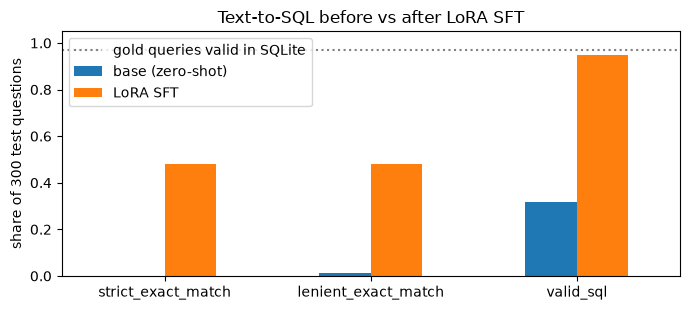

In [58]:
sql_after = evaluate_sql(sql_model)
sql_results = pd.DataFrame({
    "base (zero-shot)": {k: sql_before[k] for k in ["strict_exact_match", "lenient_exact_match", "valid_sql"]},
    "LoRA SFT": {k: sql_after[k] for k in ["strict_exact_match", "lenient_exact_match", "valid_sql"]},
}).T
print(sql_results.round(3))

fig, ax = plt.subplots(figsize=(7, 3.2))
sql_results.T.plot.bar(ax=ax, rot=0)
ax.axhline(gold_valid, color="gray", ls=":", label="gold queries valid in SQLite")
ax.set(ylabel="share of 300 test questions", title="Text-to-SQL before vs after LoRA SFT", ylim=(0, 1.05))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Step 6 — Error analysis

In [59]:
def error_type(pred, gold, schema):
    p, g = normalize_sql(pred), normalize_sql(gold)
    if p == g:
        return "exact match"
    if not is_valid_sql(schema, pred):
        return "invalid SQL"
    agg = lambda s: tuple(re.findall(r"\b(count|sum|avg|min|max)\s*\(", s))
    select_part = lambda s: s.split(" from ")[0]
    literals = lambda s: sorted(re.findall(r"'([^']*)'", s))
    if agg(p) != agg(g):
        return "wrong aggregation"
    if select_part(p) != select_part(g):
        return "wrong SELECT columns"
    if literals(p) != literals(g):
        return "different WHERE literal / quoting"
    return "other structural difference"


analysis = pd.DataFrame({"question": sql_test["question"], "gold": sql_test["answer"], "prediction": sql_after["extracted"]})
analysis["error_type"] = [error_type(p, g, c) for p, g, c in zip(analysis["prediction"], analysis["gold"], sql_test["context"])]
error_counts = analysis["error_type"].value_counts()
print(error_counts.to_string())
analysis[analysis.error_type != "exact match"].head(6)

error_type
exact match                          144
different WHERE literal / quoting     78
wrong aggregation                     38
invalid SQL                           16
other structural difference           14
wrong SELECT columns                  10


,question,gold,prediction,error_type
0,"What are the average net yards that have 9 as the touchdowns, 145 as the attempts, and...",SELECT AVG(net_yards) FROM table_name_87 WHERE touchdowns = 9 AND attempts = 145 AND y...,SELECT AVG(net_yards) FROM table_name_87 WHERE yards_per_attempt > 4.8 AND touchdowns ...,other structural difference
1,What is the mother tongue language shared by 300 people in 2006?,SELECT mother_tongue FROM table_name_94 WHERE population__2006_ = 300,"SELECT mother_tongue FROM table_name_94 WHERE population__2006_ = ""300""",different WHERE literal / quoting
3,"Who has the title and rank 14, and a worldwide gross of $202,292,902?","SELECT title FROM table_name_83 WHERE rank > 14 AND worldwide_gross = ""$202,292,902""","SELECT title FROM table_name_83 WHERE worldwide_gross = ""14"" AND rank = 14",different WHERE literal / quoting
11,What is the lowest amount of money a player from South Africa with a to par less than ...,"SELECT MIN(money___) AS $__ FROM table_name_13 WHERE country = ""south africa"" AND to_p...","SELECT MIN(money___) FROM table_name_13 WHERE country = ""south africa"" AND to_par < 8",wrong SELECT columns
13,During which years did number 13 play for the Rockets?,"SELECT years_for_rockets FROM table_11734041_3 WHERE no_s_ = ""13""","SELECT years_for_rockets FROM table_11734041_3 WHERE no_s_ = ""number 13""",different WHERE literal / quoting
14,"Who was the opponent during the game that had more than 31,891 people in attendance?",SELECT opponent FROM table_name_80 WHERE attendance > 31 OFFSET 891,SELECT opponent FROM table_name_80 WHERE attendance > 31891,other structural difference


### Step 7 — Forgetting check

The same ARC-Easy and WikiText-2 probe as Section 13, compared with the base model's numbers computed there (identical base weights and questions).

In [60]:
probes["text-to-SQL SFT (LoRA)"] = general_probe(sql_model)
low, high = paired_bootstrap_ci(probes["text-to-SQL SFT (LoRA)"]["arc_correct"], probes["base model"]["arc_correct"])
sql_forgetting = pd.DataFrame({name: {"ARC-Easy acc": probes[name]["arc_correct"].mean(), "WikiText-2 ppl": probes[name]["wikitext_ppl"]}
                               for name in ["base model", "text-to-SQL SFT (LoRA)"]}).T
print(sql_forgetting.round(3))
print(f"ARC difference 95% CI: [{low:+.3f}, {high:+.3f}]")

                        ARC-Easy acc  WikiText-2 ppl
base model                     0.485          23.540
text-to-SQL SFT (LoRA)         0.490          23.905
ARC difference 95% CI: [-0.030, +0.045]


### Step 8 — Conclusions (computed)

In [61]:
em_gain = sql_after["lenient_exact_match"] - sql_before["lenient_exact_match"]
correct_after = np.array([normalize_sql(e) == normalize_sql(g) for e, g in zip(sql_after["extracted"], sql_test["answer"])])
em_low, em_high = np.percentile(correct_after[np.random.default_rng(SEED).integers(0, len(correct_after), (2_000, len(correct_after)))].mean(1), [2.5, 97.5])
ppl_change = probes["text-to-SQL SFT (LoRA)"]["wikitext_ppl"] / probes["base model"]["wikitext_ppl"] - 1
arc_verdict = "no statistically significant change" if low <= 0 <= high else ("a significant drop" if high < 0 else "a significant gain")
top_error = error_counts.drop("exact match", errors="ignore").idxmax()

print(f"1. Exact match (lenient) went from {sql_before['lenient_exact_match']:.1%} to {sql_after['lenient_exact_match']:.1%} "
      f"({em_gain:+.1%}; 95% bootstrap CI of the after-score [{em_low:.1%}, {em_high:.1%}]) on {len(sql_test)} unseen questions.")
print(f"2. Strict format compliance: {sql_before['strict_exact_match']:.1%} → {sql_after['strict_exact_match']:.1%} — "
      "the adapter mostly taught the model to answer with bare SQL.")
print(f"3. Valid SQL: {sql_before['valid_sql']:.1%} → {sql_after['valid_sql']:.1%} (gold queries: {gold_valid:.1%}).")
print(f"4. Cost: {sql_trainable:,} trainable parameters ({sql_trainable / n_smol:.2%}), {sql_train_seconds:.0f}s of training on {DEVICE}, "
      f"a {(SQL_ADAPTER / 'adapter_model.safetensors').stat().st_size / 1e6:.1f} MB adapter.")
print(f"5. Most common remaining error: '{top_error}' ({error_counts[top_error]} of {len(sql_test)} questions).")
print(f"6. Forgetting: ARC-Easy shows {arc_verdict} (CI [{low:+.3f}, {high:+.3f}]); WikiText-2 perplexity changed {ppl_change:+.1%}.")

del sql_trainer, sql_model, sql_base
for leftover in ["sft_emotion", "dpo_truthy", "sft_sql"]:
    shutil.rmtree(OUTPUT_DIR / leftover, ignore_errors=True)
free_memory()
print("\nkept adapters:", sorted(p.name for p in OUTPUT_DIR.iterdir()))

1. Exact match (lenient) went from 1.3% to 48.0% (+46.7%; 95% bootstrap CI of the after-score [42.3%, 53.7%]) on 300 unseen questions.
2. Strict format compliance: 0.0% → 48.0% — the adapter mostly taught the model to answer with bare SQL.
3. Valid SQL: 31.7% → 94.7% (gold queries: 97.0%).
4. Cost: 4,884,480 trainable parameters (3.63%), 240s of training on mps, a 19.6 MB adapter.
5. Most common remaining error: 'different WHERE literal / quoting' (78 of 300 questions).
6. Forgetting: ARC-Easy shows no statistically significant change (CI [-0.030, +0.045]); WikiText-2 perplexity changed +1.6%.



kept adapters: ['emotion_lora_adapter', 'sql_lora_adapter', 'truthy_dpo_adapter']


**Stretch goals**

1. **Tune honestly:** carve a validation split out of the training pool and compare `r ∈ {8, 32}` and 1 vs 2 epochs; touch the test set once at the end.
2. **DPO on your own mistakes:** for training questions the SFT model gets wrong, build pairs (chosen = gold SQL, rejected = the model's query) and run `DPOTrainer`; does exact match improve beyond SFT?
3. **Execution accuracy:** populate the tables with rows (or use the Spider/BIRD databases) and compare query *results*, which credits equivalent queries written differently.
4. **Scale up on Colab:** repeat with `Qwen/Qwen2.5-0.5B-Instruct` or a 1.5B model using QLoRA (Section 6's guarded cell) and compare cost vs accuracy.
5. **Full fine-tuning vs LoRA:** train all weights with a 10× lower learning rate and compare both exact match *and* the forgetting probe.

### 🗣️ How to talk about this in an interview
- "I adapted a 135M chat model to text-to-SQL with a rank-16 LoRA on all linear layers using TRL's SFTTrainer, with prompt tokens masked so the loss was only on the SQL."
- "I de-duplicated question–schema pairs and removed test questions that appeared in training, fixed the recipe before looking at the test set, and evaluated 300 unseen questions before and after with exact match, a lenient extractor for the chatty baseline, and SQLite validity."
- "Exact match rose from near zero to the level printed in Step 8, mostly because the model learned the output format and schema-grounded column names; I bucketed the remaining errors into invalid SQL, wrong columns, aggregation, and literal mismatches."
- "I checked for catastrophic forgetting with ARC-Easy log-likelihood accuracy and WikiText-2 perplexity, using a paired bootstrap so I wouldn't over-read small differences."
- "Next I'd measure execution accuracy on populated databases and try DPO on the model's own wrong queries."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. When would you fine-tune an LLM instead of using RAG or prompting?**

<details><summary>Show answer</summary>

- **30-second answer:** Prompting first as a baseline. **RAG** when the gap is *knowledge* — private, fast-changing, or needing citations. **Fine-tuning** when the gap is *behaviour* — a strict output format, a tone, a narrow task at high volume, or making a small cheap model match a big one on one task. They combine: fine-tune a model to use retrieved context well.
- **Go deeper:** Fine-tuning is a poor way to inject facts: it is hard to update, hallucination-prone, and gives no provenance. Decide with an evaluation set and a cost/latency budget; fine-tuning also lets you drop long few-shot prompts, cutting tokens per request.
- **❌ Common wrong answer:** "Fine-tune the model on our documents so it knows them" — that's usually a RAG problem.

</details>

**Q2. Explain LoRA. How do you choose rank, alpha, and target modules?**

<details><summary>Show answer</summary>

- **30-second answer:** Freeze W and learn ΔW = (α/r)·B·A with A ∈ ℝ^{r×d_in}, B ∈ ℝ^{d_out×r}; B starts at zero so training starts from the base model. Parameters per matrix: r(d_in + d_out). Start with r = 16, α = 16–32, all linear layers (attention + MLP), and a learning rate around 1e-4–2e-4; raise r for harder or more different tasks.
- **Go deeper:** α/r keeps the update's scale stable when you change r (rsLoRA uses α/√r for large ranks). Attention-only q/v adapters were the original paper's choice; adapting all linear layers usually wins for LLMs at equal parameter budget. Merge for zero-latency serving or keep separate for multi-adapter serving. DoRA splits magnitude and direction.
- **❌ Common wrong answer:** "r is the number of layers" or "LoRA always adds inference latency."

</details>

**Q3. How much memory does QLoRA save, and how?**

<details><summary>Show answer</summary>

- **30-second answer:** The frozen base goes from 16 bits to about 4.1 bits per parameter — NF4 4-bit codes in blocks of 64 plus double-quantized scale constants (~0.127 bits) — so a 65B model's weights shrink from ~130 GB to ~33.5 GB. Only the LoRA adapters have gradients and optimizer states, and paged optimizers absorb memory spikes. That's how the QLoRA paper fine-tuned 65B models on one 48 GB GPU.
- **Go deeper:** NF4 places code values at normal-distribution quantiles because pretrained weights are roughly normal, so it wastes fewer codes than uniform 4-bit (this notebook measured lower reconstruction error on real weights). Costs: slower steps from dequantization, CUDA-only kernels in bitsandbytes, and a small quality gap. Activations still need gradient checkpointing.
- **❌ Common wrong answer:** "QLoRA trains a 4-bit model" — the adapters train in 16-bit; the 4-bit base is frozen.

</details>

**Q4. Why do we mask prompt tokens in SFT?**

<details><summary>Show answer</summary>

- **30-second answer:** The prompt is supplied at inference, so predicting it is wasted learning; with long prompts and short answers, unmasked loss is dominated by the prompt (Pitfall 1 measured most of the loss coming from prompt tokens) and the model can learn to parrot instructions. Set prompt labels to -100 so cross-entropy ignores them, and keep the EOS/end-of-turn token as a target.
- **Go deeper:** In TRL, prompt–completion datasets mask automatically (`completion_only_loss`); multi-turn chats use `assistant_only_loss` with a template that marks assistant spans. Some work finds small benefits from partial prompt loss on tiny datasets, but masking is the standard default.
- **❌ Common wrong answer:** "Masking is for padding only."

</details>

**Q5. Compare SFT, RLHF with PPO, and DPO.**

<details><summary>Show answer</summary>

- **30-second answer:** **SFT** imitates demonstrations with next-token loss. **RLHF/PPO** trains a reward model on human comparisons, then optimizes the policy online to maximize reward − β·KL to a reference (four models, sampling, finicky). **DPO** uses the closed-form optimal policy of that objective to turn preference pairs into a classification loss on policy/reference log-ratios — no reward model, no sampling, two models (or one with LoRA).
- **Go deeper:** DPO is offline: it can't explore beyond the data, and it's sensitive to distribution shift between the preference data and the policy; online methods (PPO, GRPO, online/iterative DPO) generate fresh samples. GRPO drops the critic with group-normalized rewards and shines with verifiable rewards.
- **❌ Common wrong answer:** "DPO is RL with a reward model" or "SFT and DPO are interchangeable."

</details>

**Q6. In DPO, what do β and the reference model do?**

<details><summary>Show answer</summary>

- **30-second answer:** The implicit reward is β·log(π_θ/π_ref); the loss is −log σ(β·[chosen log-ratio − rejected log-ratio]). The reference (usually the SFT model, frozen) anchors the policy — the KL constraint from RLHF inside the loss. β sets the anchor's strength: small β allows larger drift, large β keeps the policy close.
- **Go deeper:** Log-probs are **summed** over response tokens (TRL's default `sigmoid` loss), so length matters. At step 0 the policy equals the reference, all rewards are 0, and the loss is log 2. With PEFT, TRL gets the reference by disabling the adapter. `precompute_ref_log_probs` saves compute when the reference is fixed.
- **❌ Common wrong answer:** "β is the learning rate" or "the reference model is updated with the policy."

</details>

**Q7. What is reward hacking / over-optimization, and how do you detect and prevent it?**

<details><summary>Show answer</summary>

- **30-second answer:** The policy exploits flaws in the reward signal instead of getting better — longer, more flattering, or keyword-stuffed answers that the reward model (or implicit reward) likes but humans don't. Past a point, proxy reward keeps rising while true quality falls (Gao et al., 2022).
- **Go deeper:** Detect with held-out human or calibrated LLM-judge win rates, length-controlled evaluation, KL to the reference, and for DPO both chosen and rejected log-probs falling. Prevent with a KL penalty/higher β, early stopping, reward-model ensembles and refreshing on new policy samples, length normalization (SimPO), and verifiable rewards where possible.
- **❌ Common wrong answer:** "If the reward goes up, the model is better."

</details>

**Q8. What is catastrophic forgetting and how do you manage it when fine-tuning?**

<details><summary>Show answer</summary>

- **30-second answer:** Narrow training degrades general abilities. Measure it with a general benchmark before and after (this notebook: ARC-Easy + WikiText perplexity with bootstrap CIs). Limit it with LoRA, a low learning rate, few epochs, mixing in general instruction data (replay), and a KL anchor during preference tuning.
- **Go deeper:** "LoRA Learns Less and Forgets Less" (Biderman et al., 2024) found LoRA forgets less than full fine-tuning but also learns less on distant domains. Keep safety and refusal behaviour in the probe — fine-tuning on benign data has been shown to weaken safety guardrails.
- **❌ Common wrong answer:** "LoRA can't forget because the base weights are frozen" — the adapter still changes the function the model computes.

</details>

**Q9. Data quality vs quantity for SFT — what matters more?**

<details><summary>Show answer</summary>

- **30-second answer:** Quality, diversity, and consistency first. LIMA showed 1,000 carefully curated examples could align a 65B model surprisingly well; noisy, inconsistent, or duplicated data teaches the noise. Then scale quantity for coverage of the real input distribution.
- **Go deeper:** De-duplicate (exact and near-duplicate), remove test-set overlap, keep formats consistent, balance task types, filter with rules or LLM judges and spot-check by hand. For preference data, label agreement matters — noisy pairs cap achievable reward accuracy. Synthetic data from a stronger model works but check the license and diversity.
- **❌ Common wrong answer:** "More data always wins, so scrape everything."

</details>

### 💻 Coding

**Q10. Implement the DPO loss given sequence log-probabilities.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def dpo_loss(pc, pr, rc, rr, beta=0.1):
      margin = (pc - rc) - (pr - rr)                 # chosen log-ratio − rejected log-ratio
      return -F.logsigmoid(beta * margin).mean()
  ```
  where each input is the **sum** of response-token log-probs (prompt masked) under the policy or the frozen reference.
- **Go deeper:** Use `logsigmoid`, not `log(sigmoid)`, for numerical stability. Log rewards β·(pc − rc) and β·(pr − rr), their margin, and accuracy. This notebook's Build It From Scratch matches TRL's `compute_loss` on a real batch.
- **❌ Common wrong answer:** Averaging token log-probs (a different objective) or forgetting the reference terms.

</details>

**Q11. Write a LoRA linear layer.**

<details><summary>Show answer</summary>

- **30-second answer:** Keep `base = nn.Linear` frozen; add `A = nn.Parameter(r × d_in)` with Kaiming-uniform init and `B = nn.Parameter(zeros(d_out × r))`; `forward = base(x) + (x @ A.T @ B.T) * (alpha / r)`; merge with `W + (alpha / r) * B @ A`.
- **Go deeper:** Apply dropout to the LoRA branch input only; only A and B require grad; for batched multi-adapter serving, gather per-request A/B matrices. Verify by copying weights into PEFT's layer and asserting equal outputs.
- **❌ Common wrong answer:** Initializing both A and B randomly (the model no longer starts at the base) or scaling by r/α.

</details>

### 🐛 Debugging Scenarios

**Q12. After SFT your model gives the right answer but keeps generating text until `max_new_tokens`. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The end-of-turn/EOS token was never a training target — typically because `pad_token == eos_token` and the collator masked every pad-id position (Pitfall 3), or the template/formatting function didn't append EOS. Fix the labels (mask padding by position), and check `generation_config.eos_token_id` includes the chat end-of-turn token.
- **Go deeper:** Inspect a collated batch: decode the positions with labels ≠ -100 and confirm they end with the end-of-turn token. Also make sure inference uses the same chat template.
- **❌ Common wrong answer:** "Lower the temperature" or "increase training epochs."

</details>

**Q13. During DPO, reward accuracy hits 100% and margins keep growing, but generations look worse. What's happening?**

<details><summary>Show answer</summary>

- **30-second answer:** Over-optimization: the policy separates the training pairs by pushing log-probs of *both* answers down (chosen falls less), drifting from the reference into degenerate text. Check held-out metrics, chosen/rejected log-probs, KL to reference, and sample generations.
- **Go deeper:** Mitigate with fewer steps or a lower learning rate, higher β, adding an SFT term on chosen answers (RPO / `loss_type=["sigmoid", "sft"]` in TRL), filtering noisy pairs, or IPO. Evaluate with win rates, not training margins.
- **❌ Common wrong answer:** "100% reward accuracy means the model is perfectly aligned."

</details>

### 🏗️ Design

**Q14. Design an evaluation plan for a fine-tuned customer-support model before launch.**

<details><summary>Show answer</summary>

- **30-second answer:** A frozen, de-duplicated held-out set of real tickets with task metrics (exact match for structured fields, rubric-based LLM-judge scores calibrated against human labels for free text), the same metrics on the base model and the current production system, a general-ability and safety probe for regressions, latency/cost per request, and a small human side-by-side review; then a canary or A/B test.
- **Go deeper:** Slice by language, product, and ticket length; report confidence intervals; guard against leakage from training data; version the eval set, prompts, adapters, and base revision together; monitor drift after launch.
- **❌ Common wrong answer:** "Training loss went down and a few examples looked good."

</details>

**Q15. You must serve fine-tuned models for 300 enterprise customers on a small GPU fleet. What's your architecture?**

<details><summary>Show answer</summary>

- **30-second answer:** One shared base model per GPU group plus one LoRA adapter per customer, served by a multi-LoRA server (vLLM or LoRAX) that batches requests for different adapters together and caches hot adapters in GPU memory with LRU eviction from CPU/disk. Adapters are small (MBs), so onboarding a customer is a file upload, not a new deployment.
- **Go deeper:** Pin the base model revision for all adapters, run per-adapter evaluation gates, isolate tenants' data in training, rate-limit per tenant, and merge only the few highest-traffic adapters into dedicated replicas if latency demands it.
- **❌ Common wrong answer:** "Deploy 300 merged 7B models."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** How many parameters does LoRA with `r = 4` add to SmolLM2's `k_proj`, an `nn.Linear(576, 192)`?
<details><summary>Answer</summary>

`3,072` = 4 × (576 + 192).
</details>

**2.** What is the DPO loss at the very first step, before the policy has changed?
<details><summary>Answer</summary>

`log 2 ≈ 0.6931` — policy = reference, so every log-ratio and margin is 0 and −log σ(0) = log 2 (Section 11's "before" evaluation printed it).
</details>

**3.** `input_ids = [5, 6, 7, 8, 9]` and the prompt is the first 3 tokens. What are the SFT labels?
<details><summary>Answer</summary>

`[-100, -100, -100, 8, 9]`.
</details>

**4.** Bits per parameter for NF4 with block size 64 and double quantization (8-bit constants, second block size 256, fp32 second-level constants)?
<details><summary>Answer</summary>

`4 + 8/64 + 32/(64·256) ≈ 4.127` bits.
</details>

**5.** With `r = 16` and `lora_alpha = 32`, what is PEFT's scaling factor — and with `use_rslora=True`?
<details><summary>Answer</summary>

`2.0` (α/r) and `8.0` (α/√r = 32/4).
</details>

## 📚 Resources

### 📖 Official Docs
- [TRL — SFT Trainer](https://huggingface.co/docs/trl/sft_trainer) — dataset formats, completion-only loss, packing
- [TRL — DPO Trainer](https://huggingface.co/docs/trl/dpo_trainer) — preference formats, β, loss types, logged metrics
- [TRL — GRPO Trainer](https://huggingface.co/docs/trl/grpo_trainer) — online RL with reward functions
- [PEFT — LoRA developer guide](https://huggingface.co/docs/peft/developer_guides/lora) — init options, rsLoRA, DoRA, merging, multiple adapters
- [Transformers — bitsandbytes quantization](https://huggingface.co/docs/transformers/quantization/bitsandbytes) — 4-bit NF4 and QLoRA settings
- [Transformers — Chat templates](https://huggingface.co/docs/transformers/chat_templating) — rendering conversations correctly

### 🎥 Videos
- [Umar Jamil — Direct Preference Optimization (DPO) explained: Bradley-Terry model, log probabilities, math](https://www.youtube.com/watch?v=hvGa5Mba4c8) — derives the DPO loss from RLHF step by step, with code
- [Umar Jamil — LoRA: Low-Rank Adaptation of Large Language Models - Explained visually + PyTorch code from scratch](https://www.youtube.com/watch?v=PXWYUTMt-AU) — rank, alpha, and merging, built in PyTorch
- [Tim Dettmers — QLoRA: Efficient Finetuning of Quantized LLMs](https://www.youtube.com/watch?v=fQirE9N5q_Y) — the QLoRA author on NF4, double quantization, and paged optimizers

### 📄 Papers
- [Hu et al. (2021) — LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Dettmers et al. (2023) — QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314)
- [Ouyang et al. (2022) — Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) (InstructGPT / RLHF)
- [Rafailov et al. (2023) — Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290)
- [Zhou et al. (2023) — LIMA: Less Is More for Alignment](https://arxiv.org/abs/2305.11206) — data quality over quantity
- [Biderman et al. (2024) — LoRA Learns Less and Forgets Less](https://arxiv.org/abs/2405.09673)
- [Gao et al. (2022) — Scaling Laws for Reward Model Overoptimization](https://arxiv.org/abs/2210.10760)
- [Shao et al. (2024) — DeepSeekMath](https://arxiv.org/abs/2402.03300) (GRPO) · [Ethayarajh et al. (2024) — KTO](https://arxiv.org/abs/2402.01306) · [Hong et al. (2024) — ORPO](https://arxiv.org/abs/2403.07691) · [Meng et al. (2024) — SimPO](https://arxiv.org/abs/2405.14734)
- [Razin et al. (2024) — Unintentional Unalignment: Likelihood Displacement in Direct Preference Optimization](https://arxiv.org/abs/2410.08847)
- [Sheng et al. (2023) — S-LoRA: Serving Thousands of Concurrent LoRA Adapters](https://arxiv.org/abs/2311.03285)

### 📘 Books & Courses
- [Reinforcement Learning from Human Feedback (Nathan Lambert, free book)](https://rlhfbook.com/) — SFT, reward models, RLHF, DPO, and RL for reasoning
- [Hugging Face smol-course](https://github.com/huggingface/smol-course) — free hands-on course on instruction tuning, preference alignment, and PEFT with small models
- [Sebastian Raschka — LLMs-from-scratch (GitHub)](https://github.com/rasbt/LLMs-from-scratch) — includes instruction fine-tuning and DPO implemented in plain PyTorch

### 🏋️ Practice
- [TRL example scripts](https://github.com/huggingface/trl/tree/main/examples) — reference SFT/DPO/GRPO training scripts to adapt
- [Hugging Face Datasets — preference data](https://huggingface.co/datasets?search=dpo) — browse real preference datasets, then fine-tune a small model and evaluate it before/after

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Prompt vs RAG vs fine-tune | pick the cheapest fix that works | RAG = knowledge · fine-tune = behaviour · prompt = baseline |
| Training stages | pretrain → SFT → preference tuning (→ RL on verifiable rewards) | next-token CE · masked CE · DPO/PPO/GRPO |
| SFT data | chat-formatted prompt–completion pairs | `apply_chat_template`; labels = −100 on prompt; keep EOS/end-of-turn |
| Padding vs packing | reduce wasted compute | `group_by_length`, `SFTConfig(packing=True, packing_strategy="bfd")`, `trl.pack_dataset` |
| Full FT memory | model states for mixed-precision Adam | 16 bytes/param (2 + 2 + 4 + 4 + 4) + activations |
| LoRA | low-rank update beside frozen W | $W + \frac{\alpha}{r}BA$; params r(d_in + d_out); `LoraConfig(r, lora_alpha, target_modules="all-linear")` |
| QLoRA | 4-bit frozen base + 16-bit LoRA | NF4 block 64 + double quant ≈ 4.127 bits/param; `BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)`; `optim="paged_adamw_8bit"` (CUDA) |
| SFT with TRL | train on demonstrations | `SFTTrainer(model, args=SFTConfig(...), train_dataset, processing_class=tok, peft_config=LoraConfig(...))` |
| Adapters | save, reload, merge | `save_pretrained` · `PeftModel.from_pretrained(base, dir)` · `merge_and_unload()` |
| RLHF (PPO) | reward model + online RL with KL anchor | maximize $r_\phi(x,y) - \beta\log\frac{\pi_\theta}{\pi_\text{ref}}$ |
| DPO | preference pairs → classification loss | $-\log\sigma(\beta[(\log\pi_c - \log\pi^\text{ref}_c) - (\log\pi_r - \log\pi^\text{ref}_r)])$, summed token log-probs; `DPOTrainer(model, args=DPOConfig(beta=0.1), ...)` |
| GRPO | critic-free online RL | advantage = (r − mean(r)) / std(r) within a group of samples; `GRPOTrainer(reward_funcs=...)` |
| Evaluation | prove it worked | held-out split, same metric before/after, baseline, strict + lenient metrics, bootstrap CIs, samples |
| Forgetting | detect regressions | general probe (ARC log-likelihood, perplexity) before/after; LoRA, low LR, replay data |
| Multi-adapter serving | many tasks, one base | `load_adapter` / `set_adapter`; vLLM `--enable-lora`, LoRAX, S-LoRA |

## ➡️ What's Next

**[08 · LLM Inference and Serving](08_LLM_Inference_and_Serving.ipynb)** — you can now adapt a model; next you'll learn how to serve it fast and cheaply: KV-cache memory math, continuous batching, quantization for inference, and serving LoRA adapters in production engines.

Curious how training scales beyond one GPU? The optional **[Distributed Training Overview](09_Distributed_Training_Overview.ipynb)** explains the memory math, data parallelism, ZeRO, and FSDP behind large fine-tuning runs.